qiskit_runtime_service.__init__:WARNING:2026-06-04 11:05:47,787: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-06-04 11:05:48,121: Loading instance: open-instance, plan: open
qiskit_runtime_service.backends:WARNING:2026-06-04 11:05:49,242: Using instance: open-instance, plan: open


Selected backend: ibm_marrakesh
Number of circuits: 26
Job ID: d8glo3m6983c73dq0jq0
Job status: QUEUED
Saved: ibm_distinguishability_test_results.csv


,protocol,theta,T_G_model,counts_0,counts_1,shots,P0_survival,P1_excitation
0,A,0.000000,0.000000,2046,2,2048,0.999023,0.000977
1,B,0.000000,0.000000,2048,0,2048,1.000000,0.000000
2,A,0.261799,0.130900,2013,35,2048,0.982910,0.017090
3,B,0.261799,0.130900,2027,21,2048,0.989746,0.010254
4,A,0.523599,0.261799,1916,132,2048,0.935547,0.064453
5,B,0.523599,0.261799,1943,105,2048,0.948730,0.051270
6,A,0.785398,0.392699,1755,293,2048,0.856934,0.143066
7,B,0.785398,0.392699,1796,252,2048,0.876953,0.123047
8,A,1.047198,0.523599,1598,450,2048,0.780273,0.219727
9,B,1.047198,0.523599,1575,473,2048,0.769043,0.230957


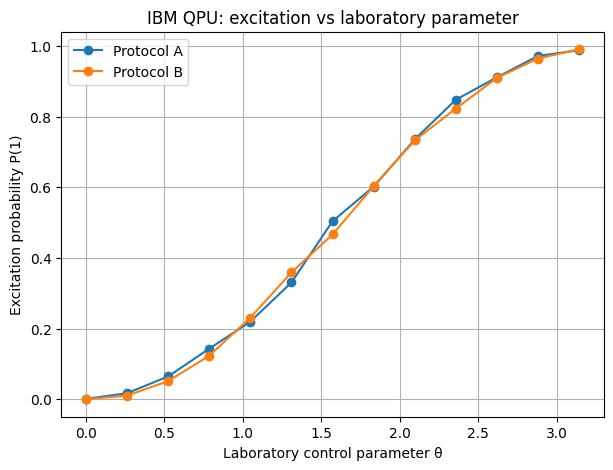

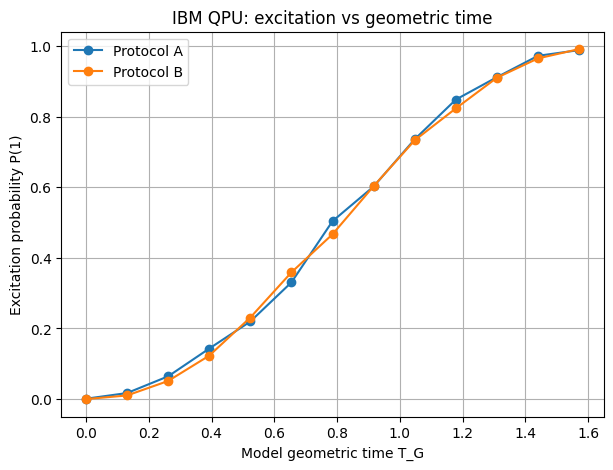

Mean |P_A - P_B|: 0.012169471153846154
Max  |P_A - P_B|: 0.037109375


protocol,A,B,abs_difference
theta,,,
0.000000,0.000977,0.000000,0.000977
0.261799,0.017090,0.010254,0.006836
0.523599,0.064453,0.051270,0.013184
0.785398,0.143066,0.123047,0.020020
1.047198,0.219727,0.230957,0.011230
1.308997,0.330566,0.358887,0.028320
1.570796,0.503906,0.466797,0.037109
1.832596,0.602051,0.603027,0.000977
2.094395,0.735840,0.732910,0.002930


In [ ]:
# ============================================================
# IBM Quantum / Colab experiment:
# Geometric-time collapse test on a real IBM QPU
# ============================================================

!pip install -q qiskit qiskit-ibm-runtime qiskit-aer matplotlib pandas numpy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit, transpile
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2 as Sampler

# ============================================================
# 1. IBM Quantum account
# ============================================================


IBM_TOKEN = "E0zjhII4C2AQn8t816MmQ8W68EiN4X1SXcomLICzTJxF"

QiskitRuntimeService.save_account(
    channel="ibm_quantum_platform",
    token=IBM_TOKEN,
    overwrite=True
)

service = QiskitRuntimeService(channel="ibm_quantum_platform")

# Можно выбрать конкретный процессор:
# backend_name = "ibm_kingston"
# backend_name = "ibm_fez"
# backend_name = "ibm_marrakesh"

backend_name = None

if backend_name is None:
    backend = service.least_busy(operational=True, simulator=False, min_num_qubits=1)
else:
    backend = service.backend(backend_name)

print("Selected backend:", backend.name)

# ============================================================
# 2. Define two different quantum trajectories
# ============================================================

# Идея:
# Protocol A: один поворот Ry(theta)
# Protocol B: два полу-поворота Ry(theta/2), Ry(theta/2)
#
# В идеальной квантовой механике итоговое состояние одинаковое.
# На реальном железе noise / pulse structure могут отличаться.
# Мы проверяем, схлопываются ли observables при параметризации через T_G.

theta_values = np.linspace(0, np.pi, 13)

def make_protocol_A(theta):
    qc = QuantumCircuit(1, 1)
    qc.ry(theta, 0)
    qc.measure(0, 0)
    return qc

def make_protocol_B(theta):
    qc = QuantumCircuit(1, 1)
    qc.ry(theta / 2, 0)
    qc.barrier()
    qc.ry(theta / 2, 0)
    qc.measure(0, 0)
    return qc

circuits = []
metadata = []

for theta in theta_values:
    qcA = make_protocol_A(theta)
    circuits.append(qcA)
    metadata.append({
        "protocol": "A",
        "theta": theta,
        "T_G_model": theta / 2
    })

    qcB = make_protocol_B(theta)
    circuits.append(qcB)
    metadata.append({
        "protocol": "B",
        "theta": theta,
        "T_G_model": theta / 2
    })

# ============================================================
# 3. Transpile to backend ISA circuits
# ============================================================

pm = generate_preset_pass_manager(
    backend=backend,
    optimization_level=1
)

isa_circuits = pm.run(circuits)

print("Number of circuits:", len(isa_circuits))

# ============================================================
# 4. Run on real IBM processor
# ============================================================

shots = 2048

sampler = Sampler(mode=backend)
job = sampler.run(isa_circuits, shots=shots)

print("Job ID:", job.job_id())
print("Job status:", job.status())

# Ждем результат.
result = job.result()

# ============================================================
# 5. Extract counts and compute survival / excitation
# ============================================================

rows = []

for i, pub_result in enumerate(result):
    # Для одно-классического регистра Qiskit обычно хранит его как "c"
    # но имя может отличаться. Пробуем безопасно извлечь counts.
    data = pub_result.data

    try:
        counts = data.c.get_counts()
    except Exception:
        # fallback: взять первый доступный регистр
        reg_name = list(data.keys())[0]
        counts = getattr(data, reg_name).get_counts()

    n0 = counts.get("0", 0)
    n1 = counts.get("1", 0)
    total = n0 + n1

    p0 = n0 / total if total > 0 else np.nan
    p1 = n1 / total if total > 0 else np.nan

    rows.append({
        **metadata[i],
        "counts_0": n0,
        "counts_1": n1,
        "shots": total,
        "P0_survival": p0,
        "P1_excitation": p1
    })

df = pd.DataFrame(rows)
df.head()

# ============================================================
# 6. Save results
# ============================================================

csv_name = "ibm_distinguishability_test_results.csv"
df.to_csv(csv_name, index=False)

print("Saved:", csv_name)
display(df)

# ============================================================
# 7. Plot: laboratory parameter theta
# ============================================================

plt.figure(figsize=(7, 5))

for protocol in ["A", "B"]:
    sub = df[df["protocol"] == protocol]
    plt.plot(sub["theta"], sub["P1_excitation"], marker="o", label=f"Protocol {protocol}")

plt.xlabel("Laboratory control parameter θ")
plt.ylabel("Excitation probability P(1)")
plt.title("IBM QPU: excitation vs laboratory parameter")
plt.legend()
plt.grid(True)
plt.show()

# ============================================================
# 8. Plot: geometric-time parameter T_G
# ============================================================

plt.figure(figsize=(7, 5))

for protocol in ["A", "B"]:
    sub = df[df["protocol"] == protocol]
    plt.plot(sub["T_G_model"], sub["P1_excitation"], marker="o", label=f"Protocol {protocol}")

plt.xlabel("Model geometric time T_G")
plt.ylabel("Excitation probability P(1)")
plt.title("IBM QPU: excitation vs geometric time")
plt.legend()
plt.grid(True)
plt.show()

# ============================================================
# 9. Collapse metric
# ============================================================

pivot = df.pivot(index="theta", columns="protocol", values="P1_excitation")
pivot["abs_difference"] = np.abs(pivot["A"] - pivot["B"])

print("Mean |P_A - P_B|:", pivot["abs_difference"].mean())
print("Max  |P_A - P_B|:", pivot["abs_difference"].max())

display(pivot)

Enter NEW IBM Quantum token: ··········


qiskit_runtime_service.__init__:WARNING:2026-06-04 11:49:58,632: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-06-04 11:49:58,946: Loading instance: open-instance, plan: open
qiskit_runtime_service.backends:WARNING:2026-06-04 11:49:59,688: Using instance: open-instance, plan: open


Selected backend: ibm_marrakesh


,protocol,theta,l_FS,T_G
0,A,0.00000,0.00000,0.000000e+00
1,B,0.00000,0.00000,0.000000e+00
2,C,0.00000,0.00000,0.000000e+00
3,A,0.15708,0.07854,2.500000e-12
4,B,0.15708,0.07854,2.500000e-12


Job ID: d8gmcq9e8nrc73bg654g
Waiting for result...


,protocol,theta,l_FS,T_G,counts_0,counts_1,shots,P0_survival,P1_excitation
0,A,0.000000,0.000000,0.000000e+00,2046,2,2048,0.999023,0.000977
1,B,0.000000,0.000000,0.000000e+00,2048,0,2048,1.000000,0.000000
2,C,0.000000,0.000000,0.000000e+00,2045,3,2048,0.998535,0.001465
3,A,0.157080,0.078540,2.500000e-12,2036,12,2048,0.994141,0.005859
4,B,0.157080,0.078540,2.500000e-12,2041,7,2048,0.996582,0.003418
...,...,...,...,...,...,...,...,...,...
58,B,2.984513,1.492257,4.750000e-11,37,2011,2048,0.018066,0.981934
59,C,2.984513,1.233282,3.925659e-11,500,1548,2048,0.244141,0.755859
60,A,3.141593,1.570796,5.000000e-11,14,2034,2048,0.006836,0.993164
61,B,3.141593,1.570796,5.000000e-11,19,2029,2048,0.009277,0.990723


Saved: ibm_true_fs_geometric_time_test.csv


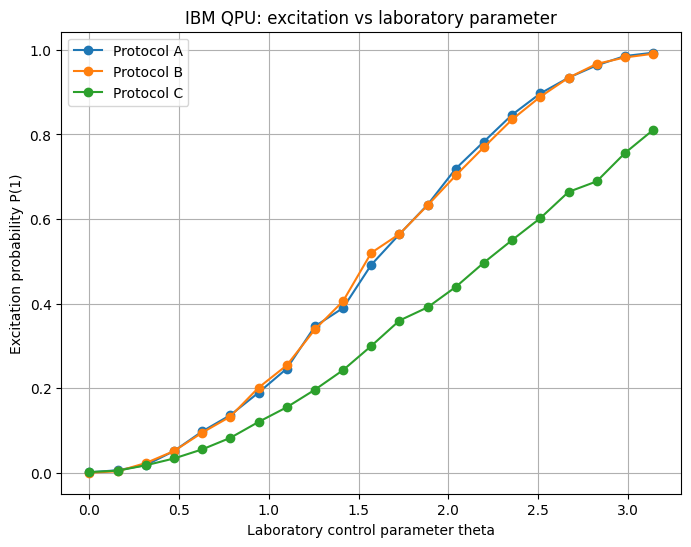

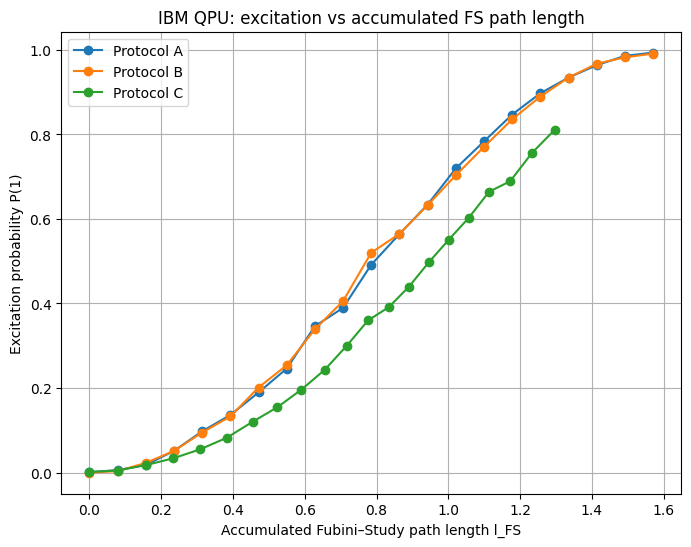

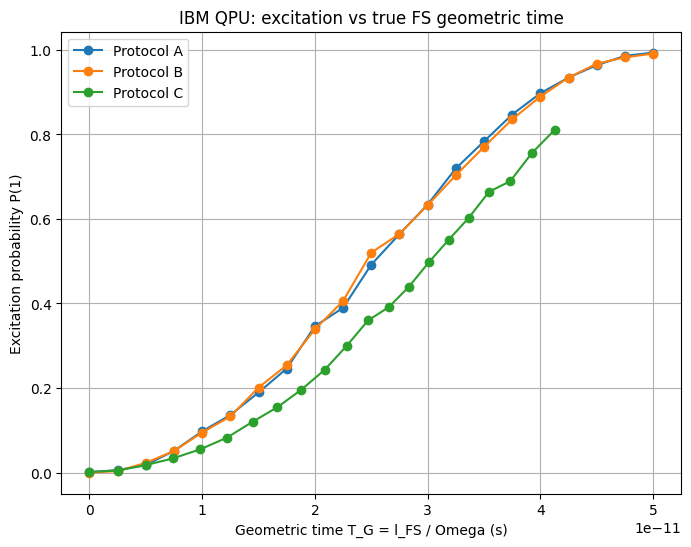

Differences at equal theta:


protocol,A,B,C,diff_A_B,diff_A_C,diff_B_C
theta,,,,,,
0.000000,0.000977,0.000000,0.001465,0.000977,0.000488,0.001465
0.157080,0.005859,0.003418,0.004883,0.002441,0.000977,0.001465
0.314159,0.018066,0.022949,0.017578,0.004883,0.000488,0.005371
0.471239,0.051270,0.051270,0.033691,0.000000,0.017578,0.017578
0.628319,0.097656,0.094727,0.055176,0.002930,0.042480,0.039551
0.785398,0.136230,0.132812,0.082520,0.003418,0.053711,0.050293
0.942478,0.189453,0.201172,0.120117,0.011719,0.069336,0.081055
1.099557,0.246094,0.253906,0.154785,0.007812,0.091309,0.099121
1.256637,0.346191,0.338867,0.196289,0.007324,0.149902,0.142578


diff_A_B mean = 0.006928943452380952 max = 0.0283203125
diff_A_C mean = 0.15836588541666666 max = 0.29638671875
diff_B_C mean = 0.15859840029761904 max = 0.287109375


,l_FS_grid,P1_A,P1_B,P1_C,abs_A_B,abs_A_C,abs_B_C
0,0.000000,0.000977,0.000000,0.001465,0.000977,0.000488,0.001465
1,0.015867,0.001963,0.000690,0.002156,0.001272,0.000193,0.001466
2,0.031733,0.002949,0.001381,0.002847,0.001568,0.000102,0.001466
3,0.047600,0.003936,0.002071,0.003538,0.001864,0.000397,0.001467
4,0.063467,0.004922,0.002762,0.004230,0.002160,0.000693,0.001468


Interpolated collapse errors:
abs_A_B mean = 0.006378778014515835 max = 0.027087279040410306
abs_A_C mean = 0.09873205239225304 max = 0.1826171875
abs_B_C mean = 0.09896152381582413 max = 0.18017578125


In [13]:
!pip install -q qiskit qiskit-ibm-runtime qiskit-aer matplotlib pandas numpy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from getpass import getpass

from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2 as Sampler


# ============================================================
# 1. IBM Quantum account
# ============================================================

IBM_TOKEN = getpass("Enter NEW IBM Quantum token: ")

QiskitRuntimeService.save_account(
    channel="ibm_quantum_platform",
    token=IBM_TOKEN,
    overwrite=True
)

service = QiskitRuntimeService(channel="ibm_quantum_platform")

backend_name = None
# backend_name = "ibm_kingston"
# backend_name = "ibm_fez"
# backend_name = "ibm_marrakesh"

backend = service.least_busy(
    operational=True,
    simulator=False,
    min_num_qubits=1
) if backend_name is None else service.backend(backend_name)

print("Selected backend:", backend.name)


# ============================================================
# 2. Parameters
# ============================================================

theta_values = np.linspace(0.0, np.pi, 21)

OMEGA = 2 * np.pi * 5e9   # spectral-gap frequency, rad/s
shots = 2048


# ============================================================
# 3. Fubini–Study distance and path length
# ============================================================

def fs_distance(psi1, psi2):
    overlap = abs(np.vdot(psi1.data, psi2.data))
    overlap = np.clip(overlap, 0.0, 1.0)
    return np.arccos(overlap)


def fs_path_length_from_circuits(step_circuits):
    psi = Statevector.from_label("0")
    total_length = 0.0

    for step in step_circuits:
        psi_next = psi.evolve(step)
        total_length += fs_distance(psi, psi_next)
        psi = psi_next

    return total_length


def geometric_time_from_steps(step_circuits):
    l_fs = fs_path_length_from_circuits(step_circuits)
    return l_fs / OMEGA, l_fs


# ============================================================
# 4. Protocol definitions
# ============================================================

def protocol_A_steps(theta):
    step = QuantumCircuit(1)
    step.ry(theta, 0)
    return [step]


def protocol_B_steps(theta):
    nsteps = 10
    steps = []

    for _ in range(nsteps):
        step = QuantumCircuit(1)
        step.ry(theta / nsteps, 0)
        steps.append(step)

    return steps


def protocol_C_steps(theta):
    nsteps = 10
    steps = []

    for _ in range(nsteps):
        step1 = QuantumCircuit(1)
        step1.rx(theta / (2 * nsteps), 0)
        steps.append(step1)

        step2 = QuantumCircuit(1)
        step2.ry(theta / (2 * nsteps), 0)
        steps.append(step2)

    return steps


def build_measured_circuit(step_circuits):
    qc = QuantumCircuit(1, 1)

    for step in step_circuits:
        qc.compose(step, inplace=True)

    qc.measure(0, 0)
    return qc


protocols = {
    "A": protocol_A_steps,
    "B": protocol_B_steps,
    "C": protocol_C_steps
}


# ============================================================
# 5. Build circuits and compute true FS geometric time
# ============================================================

circuits = []
metadata = []

for theta in theta_values:
    for label, step_maker in protocols.items():

        steps = step_maker(theta)

        T_G, l_FS = geometric_time_from_steps(steps)

        qc = build_measured_circuit(steps)

        circuits.append(qc)

        metadata.append({
            "protocol": label,
            "theta": theta,
            "l_FS": l_FS,
            "T_G": T_G
        })


df_meta = pd.DataFrame(metadata)
display(df_meta.head())


# ============================================================
# 6. Transpile and run
# ============================================================

pm = generate_preset_pass_manager(
    backend=backend,
    optimization_level=1
)

isa_circuits = pm.run(circuits)

sampler = Sampler(mode=backend)

job = sampler.run(
    isa_circuits,
    shots=shots
)

print("Job ID:", job.job_id())
print("Waiting for result...")

result = job.result()


# ============================================================
# 7. Extract counts
# ============================================================

rows = []

for i, pub_result in enumerate(result):
    data = pub_result.data

    counts = None

    for name in dir(data):
        if name.startswith("_"):
            continue

        try:
            obj = getattr(data, name)
            if hasattr(obj, "get_counts"):
                counts = obj.get_counts()
                break
        except Exception:
            pass

    if counts is None:
        raise RuntimeError(
            f"Could not extract counts for circuit {i}. Data object: {data}"
        )

    n0 = counts.get("0", 0)
    n1 = counts.get("1", 0)
    total = n0 + n1

    rows.append({
        **metadata[i],
        "counts_0": n0,
        "counts_1": n1,
        "shots": total,
        "P0_survival": n0 / total if total else np.nan,
        "P1_excitation": n1 / total if total else np.nan
    })


df = pd.DataFrame(rows)
display(df)

df.to_csv("ibm_true_fs_geometric_time_test.csv", index=False)

print("Saved: ibm_true_fs_geometric_time_test.csv")


# ============================================================
# 8. Plot versus laboratory theta
# ============================================================

plt.figure(figsize=(8, 6))

for protocol in sorted(df["protocol"].unique()):
    sub = df[df["protocol"] == protocol]
    plt.plot(
        sub["theta"],
        sub["P1_excitation"],
        marker="o",
        label=f"Protocol {protocol}"
    )

plt.xlabel("Laboratory control parameter theta")
plt.ylabel("Excitation probability P(1)")
plt.title("IBM QPU: excitation vs laboratory parameter")
plt.legend()
plt.grid(True)
plt.show()


# ============================================================
# 9. Plot versus true FS path length
# ============================================================

plt.figure(figsize=(8, 6))

for protocol in sorted(df["protocol"].unique()):
    sub = df[df["protocol"] == protocol]
    plt.plot(
        sub["l_FS"],
        sub["P1_excitation"],
        marker="o",
        label=f"Protocol {protocol}"
    )

plt.xlabel("Accumulated Fubini–Study path length l_FS")
plt.ylabel("Excitation probability P(1)")
plt.title("IBM QPU: excitation vs accumulated FS path length")
plt.legend()
plt.grid(True)
plt.show()


# ============================================================
# 10. Plot versus true geometric time
# ============================================================

plt.figure(figsize=(8, 6))

for protocol in sorted(df["protocol"].unique()):
    sub = df[df["protocol"] == protocol]
    plt.plot(
        sub["T_G"],
        sub["P1_excitation"],
        marker="o",
        label=f"Protocol {protocol}"
    )

plt.xlabel("Geometric time T_G = l_FS / Omega (s)")
plt.ylabel("Excitation probability P(1)")
plt.title("IBM QPU: excitation vs true FS geometric time")
plt.legend()
plt.grid(True)
plt.show()


# ============================================================
# 11. Collapse metrics
# ============================================================

pivot_theta = df.pivot(index="theta", columns="protocol", values="P1_excitation")

print("Differences at equal theta:")
if set(["A", "B"]).issubset(pivot_theta.columns):
    pivot_theta["diff_A_B"] = np.abs(pivot_theta["A"] - pivot_theta["B"])

if set(["A", "C"]).issubset(pivot_theta.columns):
    pivot_theta["diff_A_C"] = np.abs(pivot_theta["A"] - pivot_theta["C"])

if set(["B", "C"]).issubset(pivot_theta.columns):
    pivot_theta["diff_B_C"] = np.abs(pivot_theta["B"] - pivot_theta["C"])

display(pivot_theta)

for col in pivot_theta.columns:
    if str(col).startswith("diff"):
        print(col, "mean =", pivot_theta[col].mean(), "max =", pivot_theta[col].max())


# ============================================================
# 12. Interpolated collapse comparison versus l_FS
# ============================================================

# Since protocols may not have identical l_FS values,
# compare them after interpolation on a common l_FS grid.

grid = np.linspace(df["l_FS"].min(), df["l_FS"].max(), 100)

interp = {}

for protocol in sorted(df["protocol"].unique()):
    sub = df[df["protocol"] == protocol].sort_values("l_FS")
    interp[protocol] = np.interp(
        grid,
        sub["l_FS"],
        sub["P1_excitation"]
    )

collapse_df = pd.DataFrame({"l_FS_grid": grid})

for protocol, values in interp.items():
    collapse_df[f"P1_{protocol}"] = values

if set(["A", "B"]).issubset(interp.keys()):
    collapse_df["abs_A_B"] = np.abs(collapse_df["P1_A"] - collapse_df["P1_B"])

if set(["A", "C"]).issubset(interp.keys()):
    collapse_df["abs_A_C"] = np.abs(collapse_df["P1_A"] - collapse_df["P1_C"])

if set(["B", "C"]).issubset(interp.keys()):
    collapse_df["abs_B_C"] = np.abs(collapse_df["P1_B"] - collapse_df["P1_C"])

display(collapse_df.head())

print("Interpolated collapse errors:")
for col in collapse_df.columns:
    if col.startswith("abs"):
        print(col, "mean =", collapse_df[col].mean(), "max =", collapse_df[col].max())

,protocol,theta,l_FS,d_FS_endpoint,P1_excitation
0,A,0.000000,0.000000,0.000000,0.000977
1,B,0.000000,0.000000,0.000000,0.000000
2,C,0.000000,0.000000,0.000000,0.001465
3,A,0.157080,0.078540,0.078540,0.005859
4,B,0.157080,0.078540,0.078540,0.003418
...,...,...,...,...,...
58,B,2.984513,1.492257,1.492257,0.981934
59,C,2.984513,1.233282,1.052243,0.755859
60,A,3.141593,1.570796,1.570796,0.993164
61,B,3.141593,1.570796,1.570796,0.990723


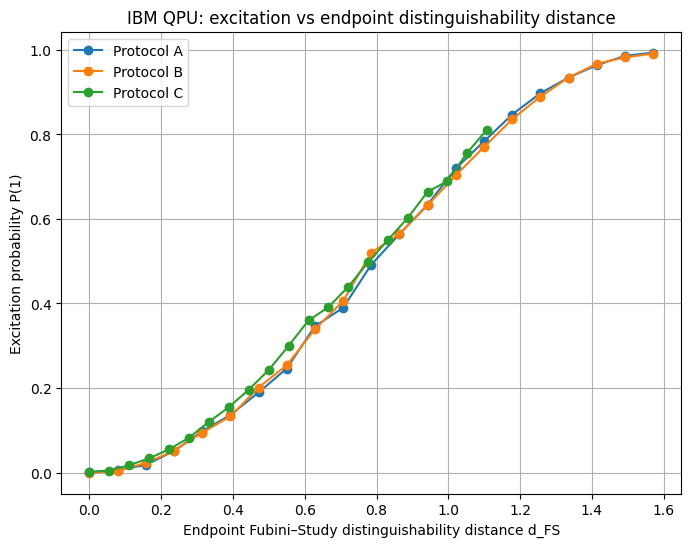

,d_FS_endpoint_grid,P1_A,P1_B,P1_C,abs_A_B,abs_A_C,abs_B_C
0,0.000000,0.000977,0.000000,0.001465,0.000977,0.000488,0.001465
1,0.015867,0.001963,0.000690,0.002441,0.001272,0.000478,0.001751
2,0.031733,0.002949,0.001381,0.003418,0.001568,0.000468,0.002037
3,0.047600,0.003936,0.002071,0.004394,0.001864,0.000459,0.002323
4,0.063467,0.004922,0.002762,0.006696,0.002160,0.001774,0.003934


Endpoint-distance collapse errors:
abs_A_B mean = 0.006378778014520152 max = 0.027087279040403867
abs_A_C mean = 0.0464372106649451 max = 0.1826171875
abs_B_C mean = 0.0448347479860315 max = 0.18017578125


In [14]:
# ============================================================
# Endpoint Fubini–Study distinguishability distance
# No new IBM job is needed. Uses existing df.
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from qiskit.quantum_info import Statevector

def endpoint_fs_distance(step_circuits):
    psi_initial = Statevector.from_label("0")
    psi_final = Statevector.from_label("0")

    for step in step_circuits:
        psi_final = psi_final.evolve(step)

    overlap = abs(np.vdot(psi_initial.data, psi_final.data))
    overlap = np.clip(overlap, 0.0, 1.0)

    return np.arccos(overlap)

# Recompute endpoint distances for all rows in df.
# This assumes protocol_A_steps, protocol_B_steps, protocol_C_steps are still defined.

endpoint_distances = []

for _, row in df.iterrows():

    theta = row["theta"]
    protocol = row["protocol"]

    if protocol == "A":
        steps = protocol_A_steps(theta)

    elif protocol == "B":
        steps = protocol_B_steps(theta)

    elif protocol == "C":
        steps = protocol_C_steps(theta)

    else:
        raise ValueError(f"Unknown protocol: {protocol}")

    d_endpoint = endpoint_fs_distance(steps)

    endpoint_distances.append(d_endpoint)

df["d_FS_endpoint"] = endpoint_distances

display(df[["protocol", "theta", "l_FS", "d_FS_endpoint", "P1_excitation"]])

# ============================================================
# Plot: excitation vs endpoint distinguishability distance
# ============================================================

plt.figure(figsize=(8, 6))

for protocol in sorted(df["protocol"].unique()):
    sub = df[df["protocol"] == protocol].sort_values("d_FS_endpoint")

    plt.plot(
        sub["d_FS_endpoint"],
        sub["P1_excitation"],
        marker="o",
        label=f"Protocol {protocol}"
    )

plt.xlabel("Endpoint Fubini–Study distinguishability distance d_FS")
plt.ylabel("Excitation probability P(1)")
plt.title("IBM QPU: excitation vs endpoint distinguishability distance")
plt.legend()
plt.grid(True)
plt.show()

# ============================================================
# Compare collapse errors after interpolation on common endpoint distance grid
# ============================================================

grid = np.linspace(df["d_FS_endpoint"].min(), df["d_FS_endpoint"].max(), 100)

interp = {}

for protocol in sorted(df["protocol"].unique()):
    sub = df[df["protocol"] == protocol].sort_values("d_FS_endpoint")

    # remove repeated x values if any
    sub = sub.drop_duplicates(subset="d_FS_endpoint")

    interp[protocol] = np.interp(
        grid,
        sub["d_FS_endpoint"],
        sub["P1_excitation"]
    )

collapse_endpoint_df = {"d_FS_endpoint_grid": grid}

for protocol, values in interp.items():
    collapse_endpoint_df[f"P1_{protocol}"] = values

import pandas as pd

collapse_endpoint_df = pd.DataFrame(collapse_endpoint_df)

if set(["A", "B"]).issubset(interp.keys()):
    collapse_endpoint_df["abs_A_B"] = np.abs(
        collapse_endpoint_df["P1_A"] - collapse_endpoint_df["P1_B"]
    )

if set(["A", "C"]).issubset(interp.keys()):
    collapse_endpoint_df["abs_A_C"] = np.abs(
        collapse_endpoint_df["P1_A"] - collapse_endpoint_df["P1_C"]
    )

if set(["B", "C"]).issubset(interp.keys()):
    collapse_endpoint_df["abs_B_C"] = np.abs(
        collapse_endpoint_df["P1_B"] - collapse_endpoint_df["P1_C"]
    )

display(collapse_endpoint_df.head())

print("Endpoint-distance collapse errors:")

for col in collapse_endpoint_df.columns:
    if col.startswith("abs"):
        print(col, "mean =", collapse_endpoint_df[col].mean(), "max =", collapse_endpoint_df[col].max())

,collapse_variable,global_mean_abs_error,global_rms_error,global_max_abs_error,abs_A_B_mean,abs_A_B_rms,abs_A_B_max,abs_A_C_mean,abs_A_C_rms,abs_A_C_max,abs_B_C_mean,abs_B_C_rms,abs_B_C_max
0,theta,0.109772,0.131411,0.296276,0.006406,0.008957,0.027707,0.161338,0.193324,0.296276,0.161572,0.191951,0.287070
1,l_FS,0.060578,0.071416,0.156426,0.007323,0.009804,0.027767,0.086998,0.102343,0.153033,0.087412,0.102102,0.156426
2,d_FS_endpoint,0.014125,0.017272,0.048045,0.006947,0.009793,0.028163,0.018292,0.021784,0.048045,0.017136,0.020238,0.040418


Saved: collapse_metric_comparison.csv


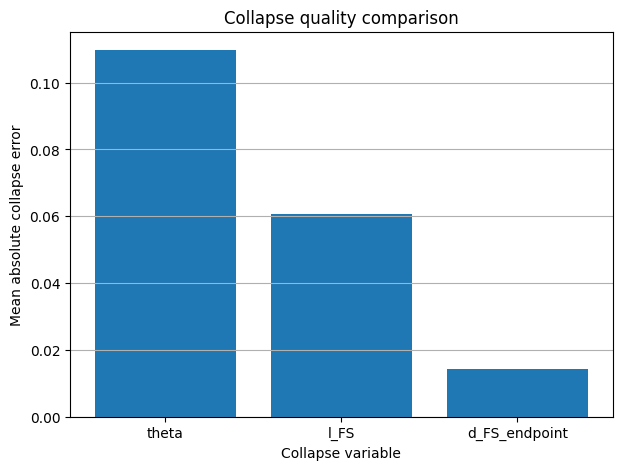

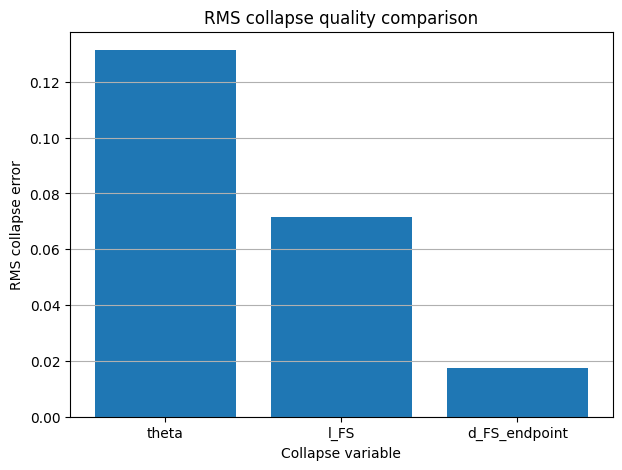

Best collapse variable:
d_FS_endpoint
Mean absolute error: 0.014124721084664412
RMS error: 0.01727205822143642
Max error: 0.048045113113869636

Full summary:
collapse_variable  global_mean_abs_error  global_rms_error  global_max_abs_error  abs_A_B_mean  abs_A_B_rms  abs_A_B_max  abs_A_C_mean  abs_A_C_rms  abs_A_C_max  abs_B_C_mean  abs_B_C_rms  abs_B_C_max
            theta               0.109772          0.131411              0.296276      0.006406     0.008957     0.027707      0.161338     0.193324     0.296276      0.161572     0.191951     0.287070
             l_FS               0.060578          0.071416              0.156426      0.007323     0.009804     0.027767      0.086998     0.102343     0.153033      0.087412     0.102102     0.156426
    d_FS_endpoint               0.014125          0.017272              0.048045      0.006947     0.009793     0.028163      0.018292     0.021784     0.048045      0.017136     0.020238     0.040418


In [15]:
# ============================================================
# Quantitative collapse comparison:
# theta vs accumulated FS length vs endpoint FS distance
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def collapse_error(df, x_col, y_col="P1_excitation", n_grid=200):
    """
    Interpolate all protocols on a common x-grid
    and compute pairwise absolute differences.
    """

    protocols = sorted(df["protocol"].unique())

    x_min = df[x_col].max() if False else max(
        df[df["protocol"] == p][x_col].min() for p in protocols
    )

    x_max = min(
        df[df["protocol"] == p][x_col].max() for p in protocols
    )

    grid = np.linspace(x_min, x_max, n_grid)

    interp = {}

    for p in protocols:
        sub = df[df["protocol"] == p].sort_values(x_col)
        sub = sub.drop_duplicates(subset=x_col)

        interp[p] = np.interp(
            grid,
            sub[x_col].values,
            sub[y_col].values
        )

    out = pd.DataFrame({x_col + "_grid": grid})

    for p in protocols:
        out[f"P1_{p}"] = interp[p]

    pair_errors = {}

    for i, p1 in enumerate(protocols):
        for p2 in protocols[i+1:]:
            name = f"abs_{p1}_{p2}"
            out[name] = np.abs(interp[p1] - interp[p2])
            pair_errors[name] = {
                "mean": out[name].mean(),
                "max": out[name].max(),
                "rms": np.sqrt(np.mean(out[name]**2))
            }

    global_mean = np.mean([v["mean"] for v in pair_errors.values()])
    global_rms = np.mean([v["rms"] for v in pair_errors.values()])
    global_max = np.max([v["max"] for v in pair_errors.values()])

    summary = {
        "x_variable": x_col,
        "global_mean_abs_error": global_mean,
        "global_rms_error": global_rms,
        "global_max_abs_error": global_max,
        "pair_errors": pair_errors
    }

    return out, summary


# ============================================================
# Run comparison
# ============================================================

variables = ["theta", "l_FS", "d_FS_endpoint"]

all_summaries = []
collapse_tables = {}

for var in variables:
    table, summary = collapse_error(df, var)
    collapse_tables[var] = table

    row = {
        "collapse_variable": var,
        "global_mean_abs_error": summary["global_mean_abs_error"],
        "global_rms_error": summary["global_rms_error"],
        "global_max_abs_error": summary["global_max_abs_error"]
    }

    for pair, vals in summary["pair_errors"].items():
        row[f"{pair}_mean"] = vals["mean"]
        row[f"{pair}_rms"] = vals["rms"]
        row[f"{pair}_max"] = vals["max"]

    all_summaries.append(row)

summary_df = pd.DataFrame(all_summaries)

display(summary_df)

summary_df.to_csv("collapse_metric_comparison.csv", index=False)
print("Saved: collapse_metric_comparison.csv")


# ============================================================
# Plot global mean collapse error
# ============================================================

plt.figure(figsize=(7, 5))

plt.bar(
    summary_df["collapse_variable"],
    summary_df["global_mean_abs_error"]
)

plt.ylabel("Mean absolute collapse error")
plt.xlabel("Collapse variable")
plt.title("Collapse quality comparison")
plt.grid(axis="y")

plt.show()


# ============================================================
# Plot global RMS collapse error
# ============================================================

plt.figure(figsize=(7, 5))

plt.bar(
    summary_df["collapse_variable"],
    summary_df["global_rms_error"]
)

plt.ylabel("RMS collapse error")
plt.xlabel("Collapse variable")
plt.title("RMS collapse quality comparison")
plt.grid(axis="y")

plt.show()


# ============================================================
# Print readable conclusion
# ============================================================

best = summary_df.sort_values("global_mean_abs_error").iloc[0]

print("Best collapse variable:")
print(best["collapse_variable"])
print("Mean absolute error:", best["global_mean_abs_error"])
print("RMS error:", best["global_rms_error"])
print("Max error:", best["global_max_abs_error"])

print("\nFull summary:")
print(summary_df.to_string(index=False))

In [16]:
# ============================================================
# Collect results from all submitted jobs
# ============================================================

all_rows = []

for backend_name, item in jobs.items():
    job = item["job"]

    print("Waiting for:", backend_name, "Job ID:", job.job_id())

    result = job.result()

    for i, pub_result in enumerate(result):
        data = pub_result.data
        counts = None

        for name in dir(data):
            if name.startswith("_"):
                continue

            try:
                obj = getattr(data, name)
                if hasattr(obj, "get_counts"):
                    counts = obj.get_counts()
                    break
            except Exception:
                pass

        if counts is None:
            raise RuntimeError(
                f"Could not extract counts for backend {backend_name}, circuit {i}"
            )

        n0 = counts.get("0", 0)
        n1 = counts.get("1", 0)
        total = n0 + n1

        all_rows.append({
            "backend": backend_name,
            **metadata[i],
            "counts_0": n0,
            "counts_1": n1,
            "shots": total,
            "P0_survival": n0 / total if total else np.nan,
            "P1_excitation": n1 / total if total else np.nan
        })

df_all = pd.DataFrame(all_rows)

display(df_all)

df_all.to_csv("ibm_three_backend_distinguishability_test.csv", index=False)

print("Saved: ibm_three_backend_distinguishability_test.csv")

NameError: name 'jobs' is not defined

Enter NEW IBM Quantum token: ··········


qiskit_runtime_service.__init__:WARNING:2026-06-04 13:24:43,725: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-06-04 13:24:44,130: Loading instance: open-instance, plan: open
qiskit_runtime_service.backends:WARNING:2026-06-04 13:24:45,683: Using instance: open-instance, plan: open


Selected backend: ibm_marrakesh


,protocol,theta,l_FS,d_FS_endpoint,T_G_path,T_G_endpoint
0,A,0.0,0.0,0.0,0.0,0.0
1,B,0.0,0.0,0.0,0.0,0.0
2,C,0.0,0.0,0.0,0.0,0.0
3,D,0.0,0.0,0.0,0.0,0.0
4,E,0.0,0.0,0.0,0.0,0.0


Number of circuits: 126
Job ID: d8gnp842upec739k2fm0
Waiting for result...


,protocol,theta,l_FS,d_FS_endpoint,T_G_path,T_G_endpoint,counts_0,counts_1,shots,P0_survival,P1_excitation
0,A,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,2041,7,2048,0.996582,0.003418
1,B,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,2044,4,2048,0.998047,0.001953
2,C,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,2046,2,2048,0.999023,0.000977
3,D,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,2047,1,2048,0.999512,0.000488
4,E,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,2046,2,2048,0.999023,0.000977
...,...,...,...,...,...,...,...,...,...,...,...
121,B,3.141593,1.570796,1.570796,5.000000e-11,5.000000e-11,17,2031,2048,0.008301,0.991699
122,C,3.141593,1.296544,1.107046,4.127027e-11,3.523836e-11,399,1649,2048,0.194824,0.805176
123,D,3.141593,2.657007,1.122964,8.457517e-11,3.574505e-11,390,1658,2048,0.190430,0.809570
124,E,3.141593,1.289671,1.100551,4.105151e-11,3.503162e-11,411,1637,2048,0.200684,0.799316


Saved: ibm_extended_protocol_distinguishability_test.csv


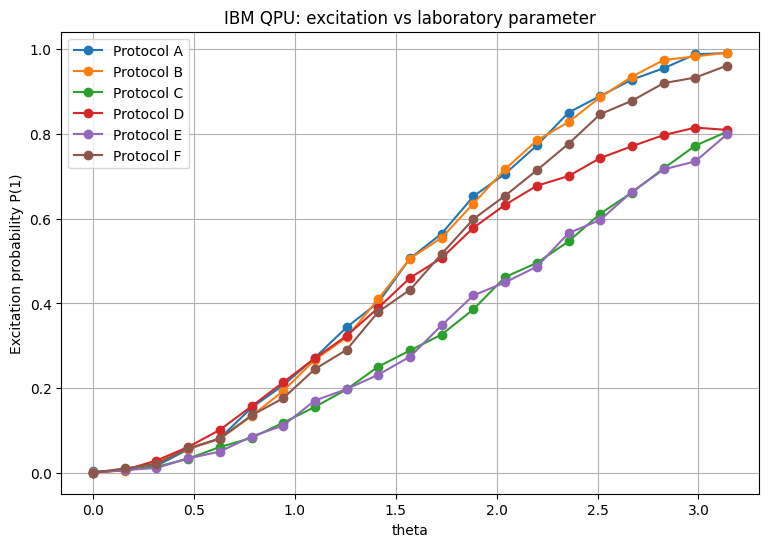

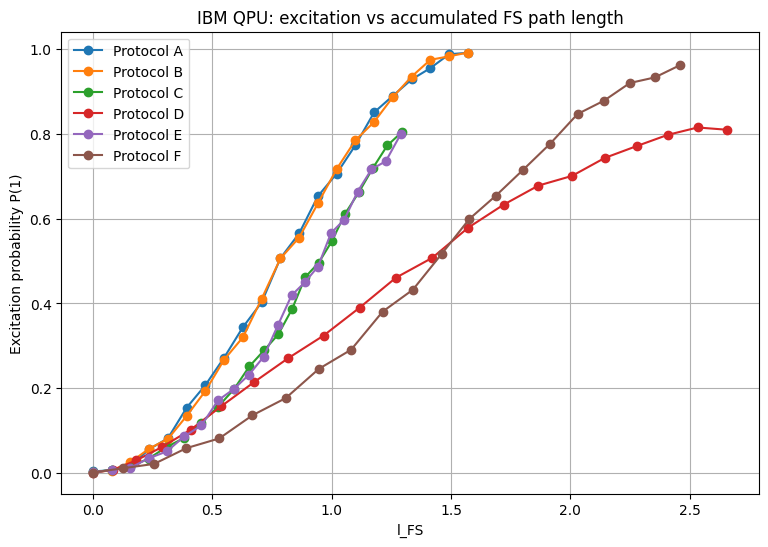

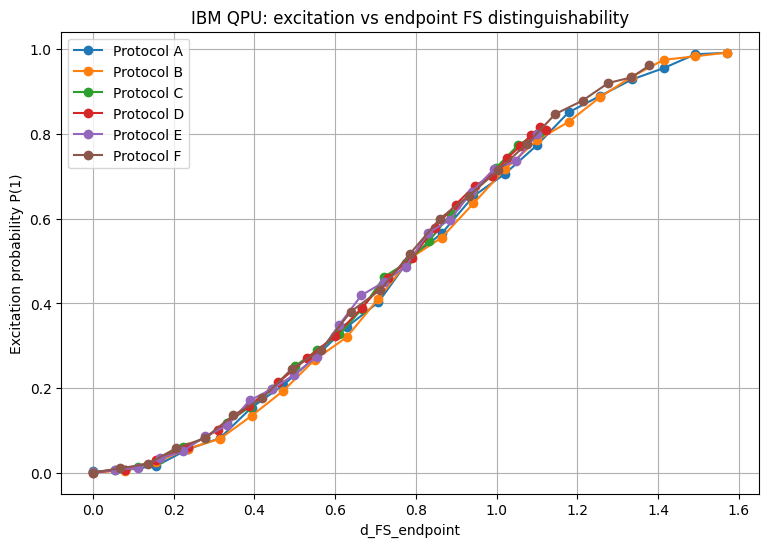

,collapse_variable,global_mean_abs_error,global_rms_error,global_max_abs_error
0,theta,0.091479,0.110693,0.303750
1,l_FS,0.117659,0.151712,0.495688
2,d_FS_endpoint,0.012463,0.015241,0.056571
3,T_G_path,0.117659,0.151712,0.495688
4,T_G_endpoint,0.012463,0.015241,0.056571


Saved: extended_collapse_metric_comparison.csv


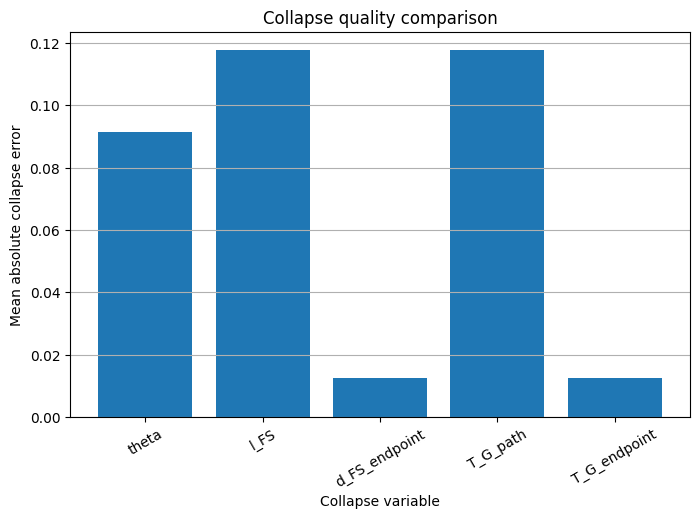

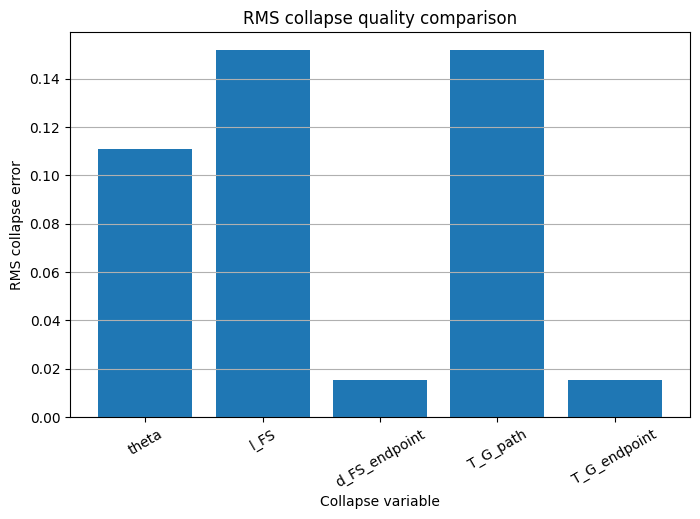

Best collapse variable: d_FS_endpoint
Mean abs error: 0.012463143847118592
RMS error: 0.015241414658149316
Max abs error: 0.05657056654465725


In [17]:
!pip install -q qiskit qiskit-ibm-runtime qiskit-aer matplotlib pandas numpy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from getpass import getpass

from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2 as Sampler


IBM_TOKEN = getpass("Enter NEW IBM Quantum token: ")

QiskitRuntimeService.save_account(
    channel="ibm_quantum_platform",
    token=IBM_TOKEN,
    overwrite=True
)

service = QiskitRuntimeService(channel="ibm_quantum_platform")

backend_name = None
# backend_name = "ibm_kingston"
# backend_name = "ibm_fez"
# backend_name = "ibm_marrakesh"

backend = service.least_busy(
    operational=True,
    simulator=False,
    min_num_qubits=1
) if backend_name is None else service.backend(backend_name)

print("Selected backend:", backend.name)

theta_values = np.linspace(0.0, np.pi, 21)
OMEGA = 2 * np.pi * 5e9
shots = 2048


def fs_distance(psi1, psi2):
    overlap = abs(np.vdot(psi1.data, psi2.data))
    overlap = np.clip(overlap, 0.0, 1.0)
    return np.arccos(overlap)


def fs_path_length_from_steps(step_circuits):
    psi = Statevector.from_label("0")
    total_length = 0.0

    for step in step_circuits:
        psi_next = psi.evolve(step)
        total_length += fs_distance(psi, psi_next)
        psi = psi_next

    return total_length


def endpoint_fs_distance(step_circuits):
    psi_initial = Statevector.from_label("0")
    psi_final = Statevector.from_label("0")

    for step in step_circuits:
        psi_final = psi_final.evolve(step)

    overlap = abs(np.vdot(psi_initial.data, psi_final.data))
    overlap = np.clip(overlap, 0.0, 1.0)
    return np.arccos(overlap)


def build_measured_circuit(step_circuits):
    qc = QuantumCircuit(1, 1)
    for step in step_circuits:
        qc.compose(step, inplace=True)
    qc.measure(0, 0)
    return qc


def protocol_A_steps(theta):
    step = QuantumCircuit(1)
    step.ry(theta, 0)
    return [step]


def protocol_B_steps(theta):
    nsteps = 10
    steps = []
    for _ in range(nsteps):
        step = QuantumCircuit(1)
        step.ry(theta / nsteps, 0)
        steps.append(step)
    return steps


def protocol_C_steps(theta):
    nsteps = 10
    steps = []
    for _ in range(nsteps):
        step1 = QuantumCircuit(1)
        step1.rx(theta / (2 * nsteps), 0)
        steps.append(step1)

        step2 = QuantumCircuit(1)
        step2.ry(theta / (2 * nsteps), 0)
        steps.append(step2)
    return steps


def protocol_D_steps(theta):
    steps = []

    for gate_name, angle in [
        ("ry", theta / 3),
        ("rz", theta / 2),
        ("ry", theta / 3),
        ("rz", -theta / 2),
        ("ry", theta / 3),
    ]:
        step = QuantumCircuit(1)
        getattr(step, gate_name)(angle, 0)
        steps.append(step)

    return steps


def protocol_E_steps(theta):
    steps = []
    nsteps = 6

    for _ in range(nsteps):
        step1 = QuantumCircuit(1)
        step1.rx(theta / (2 * nsteps), 0)
        steps.append(step1)

        step2 = QuantumCircuit(1)
        step2.ry(theta / (2 * nsteps), 0)
        steps.append(step2)

    return steps


def protocol_F_steps(theta):
    steps = []
    nsteps = 12

    pattern = [
        ("rx", 0.40),
        ("ry", 0.35),
        ("rz", 0.25),
        ("rx", -0.20),
        ("ry", 0.30),
        ("rz", -0.10),
    ]

    norm = sum(abs(x[1]) for x in pattern)

    for _ in range(2):
        for gate_name, weight in pattern:
            step = QuantumCircuit(1)
            getattr(step, gate_name)(theta * weight / norm, 0)
            steps.append(step)

    return steps


protocols = {
    "A": protocol_A_steps,
    "B": protocol_B_steps,
    "C": protocol_C_steps,
    "D": protocol_D_steps,
    "E": protocol_E_steps,
    "F": protocol_F_steps,
}


circuits = []
metadata = []

for theta in theta_values:
    for label, step_maker in protocols.items():
        steps = step_maker(theta)

        l_FS = fs_path_length_from_steps(steps)
        d_FS_endpoint = endpoint_fs_distance(steps)
        T_G_path = l_FS / OMEGA
        T_G_endpoint = d_FS_endpoint / OMEGA

        circuits.append(build_measured_circuit(steps))

        metadata.append({
            "protocol": label,
            "theta": theta,
            "l_FS": l_FS,
            "d_FS_endpoint": d_FS_endpoint,
            "T_G_path": T_G_path,
            "T_G_endpoint": T_G_endpoint
        })

df_meta = pd.DataFrame(metadata)
display(df_meta.head())
print("Number of circuits:", len(circuits))

pm = generate_preset_pass_manager(
    backend=backend,
    optimization_level=1
)

isa_circuits = pm.run(circuits)

sampler = Sampler(mode=backend)

job = sampler.run(
    isa_circuits,
    shots=shots
)

print("Job ID:", job.job_id())
print("Waiting for result...")

result = job.result()

rows = []

for i, pub_result in enumerate(result):
    data = pub_result.data
    counts = None

    for name in dir(data):
        if name.startswith("_"):
            continue
        try:
            obj = getattr(data, name)
            if hasattr(obj, "get_counts"):
                counts = obj.get_counts()
                break
        except Exception:
            pass

    if counts is None:
        raise RuntimeError(f"Could not extract counts for circuit {i}")

    n0 = counts.get("0", 0)
    n1 = counts.get("1", 0)
    total = n0 + n1

    rows.append({
        **metadata[i],
        "counts_0": n0,
        "counts_1": n1,
        "shots": total,
        "P0_survival": n0 / total if total else np.nan,
        "P1_excitation": n1 / total if total else np.nan
    })

df = pd.DataFrame(rows)
display(df)

df.to_csv("ibm_extended_protocol_distinguishability_test.csv", index=False)
print("Saved: ibm_extended_protocol_distinguishability_test.csv")


def plot_by_variable(df, x_col, title):
    plt.figure(figsize=(9, 6))

    for protocol in sorted(df["protocol"].unique()):
        sub = df[df["protocol"] == protocol].sort_values(x_col)
        plt.plot(
            sub[x_col],
            sub["P1_excitation"],
            marker="o",
            label=f"Protocol {protocol}"
        )

    plt.xlabel(x_col)
    plt.ylabel("Excitation probability P(1)")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()


plot_by_variable(
    df,
    "theta",
    "IBM QPU: excitation vs laboratory parameter"
)

plot_by_variable(
    df,
    "l_FS",
    "IBM QPU: excitation vs accumulated FS path length"
)

plot_by_variable(
    df,
    "d_FS_endpoint",
    "IBM QPU: excitation vs endpoint FS distinguishability"
)


def collapse_error(df, x_col, y_col="P1_excitation", n_grid=300):
    protocols = sorted(df["protocol"].unique())

    x_min = max(
        df[df["protocol"] == p][x_col].min()
        for p in protocols
    )

    x_max = min(
        df[df["protocol"] == p][x_col].max()
        for p in protocols
    )

    grid = np.linspace(x_min, x_max, n_grid)

    interp = {}

    for p in protocols:
        sub = df[df["protocol"] == p].sort_values(x_col)
        sub = sub.drop_duplicates(subset=x_col)

        interp[p] = np.interp(
            grid,
            sub[x_col].values,
            sub[y_col].values
        )

    out = pd.DataFrame({x_col + "_grid": grid})

    for p in protocols:
        out[f"P1_{p}"] = interp[p]

    pair_errors = {}

    for i, p1 in enumerate(protocols):
        for p2 in protocols[i + 1:]:
            name = f"abs_{p1}_{p2}"
            out[name] = np.abs(interp[p1] - interp[p2])
            pair_errors[name] = {
                "mean": out[name].mean(),
                "rms": np.sqrt(np.mean(out[name] ** 2)),
                "max": out[name].max()
            }

    global_mean = np.mean([v["mean"] for v in pair_errors.values()])
    global_rms = np.mean([v["rms"] for v in pair_errors.values()])
    global_max = np.max([v["max"] for v in pair_errors.values()])

    summary = {
        "collapse_variable": x_col,
        "global_mean_abs_error": global_mean,
        "global_rms_error": global_rms,
        "global_max_abs_error": global_max,
        "pair_errors": pair_errors
    }

    return out, summary


variables = [
    "theta",
    "l_FS",
    "d_FS_endpoint",
    "T_G_path",
    "T_G_endpoint"
]

summaries = []

for var in variables:
    table, summary = collapse_error(df, var)

    row = {
        "collapse_variable": var,
        "global_mean_abs_error": summary["global_mean_abs_error"],
        "global_rms_error": summary["global_rms_error"],
        "global_max_abs_error": summary["global_max_abs_error"]
    }

    summaries.append(row)

summary_df = pd.DataFrame(summaries)
display(summary_df)

summary_df.to_csv("extended_collapse_metric_comparison.csv", index=False)
print("Saved: extended_collapse_metric_comparison.csv")

plt.figure(figsize=(8, 5))
plt.bar(
    summary_df["collapse_variable"],
    summary_df["global_mean_abs_error"]
)
plt.ylabel("Mean absolute collapse error")
plt.xlabel("Collapse variable")
plt.title("Collapse quality comparison")
plt.xticks(rotation=30)
plt.grid(axis="y")
plt.show()

plt.figure(figsize=(8, 5))
plt.bar(
    summary_df["collapse_variable"],
    summary_df["global_rms_error"]
)
plt.ylabel("RMS collapse error")
plt.xlabel("Collapse variable")
plt.title("RMS collapse quality comparison")
plt.xticks(rotation=30)
plt.grid(axis="y")
plt.show()

best = summary_df.sort_values("global_mean_abs_error").iloc[0]

print("Best collapse variable:", best["collapse_variable"])
print("Mean abs error:", best["global_mean_abs_error"])
print("RMS error:", best["global_rms_error"])
print("Max abs error:", best["global_max_abs_error"])

In [18]:
# ============================================================
# Run the same A–F protocol set on one additional IBM backend
# Requires existing: circuits, metadata, collapse_error
# ============================================================

backend_name = "ibm_fez"
# backend_name = "ibm_marrakesh"
# backend_name = "ibm_kingston"

shots = 2048

backend = service.backend(backend_name)

print("Selected backend:", backend.name)

pm = generate_preset_pass_manager(
    backend=backend,
    optimization_level=1
)

isa_circuits = pm.run(circuits)

sampler = Sampler(mode=backend)

job = sampler.run(
    isa_circuits,
    shots=shots
)

print("Submitted job")
print("Backend:", backend_name)
print("Job ID:", job.job_id())
print("Waiting for result...")

result = job.result()

rows = []

for i, pub_result in enumerate(result):
    data = pub_result.data
    counts = None

    for name in dir(data):
        if name.startswith("_"):
            continue

        try:
            obj = getattr(data, name)
            if hasattr(obj, "get_counts"):
                counts = obj.get_counts()
                break
        except Exception:
            pass

    if counts is None:
        raise RuntimeError(f"Could not extract counts for circuit {i}")

    n0 = counts.get("0", 0)
    n1 = counts.get("1", 0)
    total = n0 + n1

    rows.append({
        "backend": backend_name,
        **metadata[i],
        "counts_0": n0,
        "counts_1": n1,
        "shots": total,
        "P0_survival": n0 / total if total else np.nan,
        "P1_excitation": n1 / total if total else np.nan
    })

df_backend = pd.DataFrame(rows)

display(df_backend)

filename = f"ibm_extended_protocol_{backend_name}.csv"
df_backend.to_csv(filename, index=False)

print("Saved:", filename)

qiskit_runtime_service.backends:WARNING:2026-06-04 13:46:52,858: Using instance: open-instance, plan: open


Selected backend: ibm_fez
Submitted job
Backend: ibm_fez
Job ID: d8go3jpe8nrc73bg8i00
Waiting for result...


,backend,protocol,theta,l_FS,d_FS_endpoint,T_G_path,T_G_endpoint,counts_0,counts_1,shots,P0_survival,P1_excitation
0,ibm_fez,A,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,2026,22,2048,0.989258,0.010742
1,ibm_fez,B,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,2031,17,2048,0.991699,0.008301
2,ibm_fez,C,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,2033,15,2048,0.992676,0.007324
3,ibm_fez,D,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,2031,17,2048,0.991699,0.008301
4,ibm_fez,E,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,2027,21,2048,0.989746,0.010254
...,...,...,...,...,...,...,...,...,...,...,...,...
121,ibm_fez,B,3.141593,1.570796,1.570796,5.000000e-11,5.000000e-11,43,2005,2048,0.020996,0.979004
122,ibm_fez,C,3.141593,1.296544,1.107046,4.127027e-11,3.523836e-11,450,1598,2048,0.219727,0.780273
123,ibm_fez,D,3.141593,2.657007,1.122964,8.457517e-11,3.574505e-11,412,1636,2048,0.201172,0.798828
124,ibm_fez,E,3.141593,1.289671,1.100551,4.105151e-11,3.503162e-11,433,1615,2048,0.211426,0.788574


Saved: ibm_extended_protocol_ibm_fez.csv


In [19]:
# ============================================================
# Run the same A–F protocol set on one additional IBM backend
# Requires existing: circuits, metadata, collapse_error
# ============================================================

backend_name = "ibm_fez"
# backend_name = "ibm_marrakesh"
# backend_name = "ibm_kingston"

shots = 2048

backend = service.backend(backend_name)

print("Selected backend:", backend.name)

pm = generate_preset_pass_manager(
    backend=backend,
    optimization_level=1
)

isa_circuits = pm.run(circuits)

sampler = Sampler(mode=backend)

job = sampler.run(
    isa_circuits,
    shots=shots
)

print("Submitted job")
print("Backend:", backend_name)
print("Job ID:", job.job_id())
print("Waiting for result...")

result = job.result()

rows = []

for i, pub_result in enumerate(result):
    data = pub_result.data
    counts = None

    for name in dir(data):
        if name.startswith("_"):
            continue

        try:
            obj = getattr(data, name)
            if hasattr(obj, "get_counts"):
                counts = obj.get_counts()
                break
        except Exception:
            pass

    if counts is None:
        raise RuntimeError(f"Could not extract counts for circuit {i}")

    n0 = counts.get("0", 0)
    n1 = counts.get("1", 0)
    total = n0 + n1

    rows.append({
        "backend": backend_name,
        **metadata[i],
        "counts_0": n0,
        "counts_1": n1,
        "shots": total,
        "P0_survival": n0 / total if total else np.nan,
        "P1_excitation": n1 / total if total else np.nan
    })

df_backend = pd.DataFrame(rows)

display(df_backend)

filename = f"ibm_extended_protocol_{backend_name}.csv"
df_backend.to_csv(filename, index=False)

print("Saved:", filename)

qiskit_runtime_service.backends:WARNING:2026-06-04 13:50:25,934: Using instance: open-instance, plan: open


Selected backend: ibm_fez
Submitted job
Backend: ibm_fez
Job ID: d8go5942upec739k32gg
Waiting for result...


,backend,protocol,theta,l_FS,d_FS_endpoint,T_G_path,T_G_endpoint,counts_0,counts_1,shots,P0_survival,P1_excitation
0,ibm_fez,A,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,2038,10,2048,0.995117,0.004883
1,ibm_fez,B,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,2035,13,2048,0.993652,0.006348
2,ibm_fez,C,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,2029,19,2048,0.990723,0.009277
3,ibm_fez,D,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,2028,20,2048,0.990234,0.009766
4,ibm_fez,E,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,2033,15,2048,0.992676,0.007324
...,...,...,...,...,...,...,...,...,...,...,...,...
121,ibm_fez,B,3.141593,1.570796,1.570796,5.000000e-11,5.000000e-11,58,1990,2048,0.028320,0.971680
122,ibm_fez,C,3.141593,1.296544,1.107046,4.127027e-11,3.523836e-11,433,1615,2048,0.211426,0.788574
123,ibm_fez,D,3.141593,2.657007,1.122964,8.457517e-11,3.574505e-11,453,1595,2048,0.221191,0.778809
124,ibm_fez,E,3.141593,1.289671,1.100551,4.105151e-11,3.503162e-11,413,1635,2048,0.201660,0.798340


Saved: ibm_extended_protocol_ibm_fez.csv


In [20]:
summary_backend_df

NameError: name 'summary_backend_df' is not defined

In [21]:
print("Best collapse variable:", ...)
print("Mean abs error:", ...)

Best collapse variable: Ellipsis
Mean abs error: Ellipsis


In [22]:
variables = [
    "theta",
    "l_FS",
    "d_FS_endpoint",
    "T_G_path",
    "T_G_endpoint"
]

summaries = []

for var in variables:

    table, summary = collapse_error(df_backend, var)

    summaries.append({
        "collapse_variable": var,
        "global_mean_abs_error": summary["global_mean_abs_error"],
        "global_rms_error": summary["global_rms_error"],
        "global_max_abs_error": summary["global_max_abs_error"]
    })

summary_backend_df = pd.DataFrame(summaries)

display(summary_backend_df)

,collapse_variable,global_mean_abs_error,global_rms_error,global_max_abs_error
0,theta,0.096097,0.115667,0.311336
1,l_FS,0.124662,0.158654,0.515494
2,d_FS_endpoint,0.007385,0.009919,0.043198
3,T_G_path,0.124662,0.158654,0.515494
4,T_G_endpoint,0.007385,0.009919,0.043198


/tmp/ipykernel_6199/1877822066.py:18: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data[col] = alpha * data["d_FS_norm"] + (1 - alpha) * data["l_FS_norm"]
/tmp/ipykernel_6199/1877822066.py:18: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data[col] = alpha * data["d_FS_norm"] + (1 - alpha) * data["l_FS_norm"]
/tmp/ipykernel_6199/1877822066.py:18: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once 

,alpha_endpoint,weight_path,mean_error,rms_error,max_error
100,1.00,0.00,0.007385,0.009919,0.043198
99,0.99,0.01,0.007771,0.010321,0.041938
98,0.98,0.02,0.008324,0.011009,0.040704
97,0.97,0.03,0.009010,0.011908,0.044970
96,0.96,0.04,0.009821,0.012949,0.050054
95,0.95,0.05,0.010706,0.014072,0.055267
94,0.94,0.06,0.011654,0.015253,0.060855
93,0.93,0.07,0.012646,0.016469,0.066634
92,0.92,0.08,0.013664,0.017713,0.072582
91,0.91,0.09,0.014707,0.018981,0.078500


Best alpha_endpoint = 1.0
Best weight_path = 0.0
Best mean error = 0.007385481710402351
Best RMS error = 0.009918765064540777


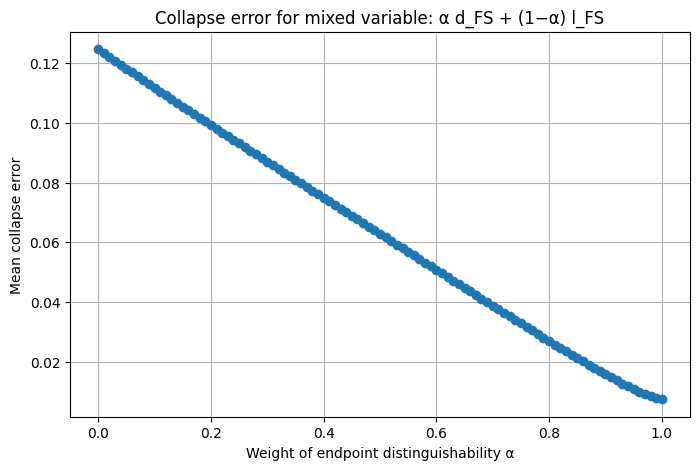

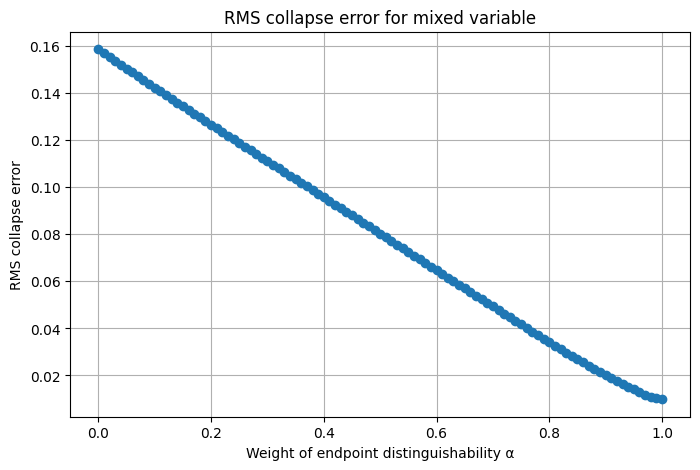

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# choose data:
data = df_backend.copy()   # for ibm_fez
# data = df.copy()         # for previous backend

# normalize variables to comparable [0,1]
data["l_FS_norm"] = data["l_FS"] / data["l_FS"].max()
data["d_FS_norm"] = data["d_FS_endpoint"] / data["d_FS_endpoint"].max()

alphas = np.linspace(0, 1, 101)
rows = []

for alpha in alphas:
    col = f"D_mix_{alpha:.2f}"
    data[col] = alpha * data["d_FS_norm"] + (1 - alpha) * data["l_FS_norm"]

    _, summary = collapse_error(data, col)

    rows.append({
        "alpha_endpoint": alpha,
        "weight_path": 1 - alpha,
        "mean_error": summary["global_mean_abs_error"],
        "rms_error": summary["global_rms_error"],
        "max_error": summary["global_max_abs_error"]
    })

mix_df = pd.DataFrame(rows)
display(mix_df.sort_values("mean_error").head(10))

best = mix_df.sort_values("mean_error").iloc[0]
print("Best alpha_endpoint =", best["alpha_endpoint"])
print("Best weight_path =", best["weight_path"])
print("Best mean error =", best["mean_error"])
print("Best RMS error =", best["rms_error"])

plt.figure(figsize=(8,5))
plt.plot(mix_df["alpha_endpoint"], mix_df["mean_error"], marker="o")
plt.xlabel("Weight of endpoint distinguishability α")
plt.ylabel("Mean collapse error")
plt.title("Collapse error for mixed variable: α d_FS + (1−α) l_FS")
plt.grid(True)
plt.show()

plt.figure(figsize=(8,5))
plt.plot(mix_df["alpha_endpoint"], mix_df["rms_error"], marker="o")
plt.xlabel("Weight of endpoint distinguishability α")
plt.ylabel("RMS collapse error")
plt.title("RMS collapse error for mixed variable")
plt.grid(True)
plt.show()

In [25]:
# ============================================================
# 3-parameter mixed collapse variable:
# D_mix = a*d_FS + b*l_FS + c*theta
# with a+b+c=1
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

data = df_backend.copy()   # текущий ibm_fez
# data = df.copy()         # если хочешь первый backend

# Normalize all variables to [0,1]
data["theta_norm"] = data["theta"] / data["theta"].max()
data["l_FS_norm"] = data["l_FS"] / data["l_FS"].max()
data["d_FS_norm"] = data["d_FS_endpoint"] / data["d_FS_endpoint"].max()

grid_step = 0.02

rows = []

a_values = np.arange(0, 1 + grid_step, grid_step)

for a in a_values:  # endpoint weight
    for b in a_values:  # path-length weight
        c = 1 - a - b  # theta weight

        if c < -1e-12:
            continue

        c = max(c, 0)

        col = f"D_mix_a{a:.2f}_b{b:.2f}_c{c:.2f}"

        data[col] = (
            a * data["d_FS_norm"]
            + b * data["l_FS_norm"]
            + c * data["theta_norm"]
        )

        _, summary = collapse_error(data, col)

        rows.append({
            "weight_d_FS": a,
            "weight_l_FS": b,
            "weight_theta": c,
            "mean_error": summary["global_mean_abs_error"],
            "rms_error": summary["global_rms_error"],
            "max_error": summary["global_max_abs_error"]
        })

mix3_df = pd.DataFrame(rows)

display(mix3_df.sort_values("mean_error").head(20))

best = mix3_df.sort_values("mean_error").iloc[0]

print("Best weights:")
print("d_FS weight =", best["weight_d_FS"])
print("l_FS weight =", best["weight_l_FS"])
print("theta weight =", best["weight_theta"])
print("Mean error =", best["mean_error"])
print("RMS error =", best["rms_error"])
print("Max error =", best["max_error"])

mix3_df.to_csv("three_parameter_collapse_scan.csv", index=False)
print("Saved: three_parameter_collapse_scan.csv")

/tmp/ipykernel_6199/313084391.py:36: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data[col] = (
/tmp/ipykernel_6199/313084391.py:36: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data[col] = (
/tmp/ipykernel_6199/313084391.py:36: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data[col] = (
/tmp/ipyke

KeyboardInterrupt: 

In [26]:
# ============================================================
# Fast 3-parameter scan
# ============================================================

import numpy as np
import pandas as pd

data = df_backend.copy()

data["theta_norm"] = data["theta"] / data["theta"].max()
data["l_FS_norm"] = data["l_FS"] / data["l_FS"].max()
data["d_FS_norm"] = data["d_FS_endpoint"] / data["d_FS_endpoint"].max()

rows = []

step = 0.1

for a in np.arange(0, 1.0001, step):

    for b in np.arange(0, 1.0001 - a, step):

        c = 1.0 - a - b

        mix_name = "D_mix"

        data[mix_name] = (
            a * data["d_FS_norm"]
            + b * data["l_FS_norm"]
            + c * data["theta_norm"]
        )

        _, summary = collapse_error(data, mix_name)

        rows.append({
            "a_dFS": a,
            "b_lFS": b,
            "c_theta": c,
            "mean_error": summary["global_mean_abs_error"],
            "rms_error": summary["global_rms_error"]
        })

result_df = pd.DataFrame(rows)

result_df = result_df.sort_values("mean_error")

display(result_df.head(20))

best = result_df.iloc[0]

print("\nBEST COMBINATION")
print("----------------")
print("d_FS weight  =", best["a_dFS"])
print("l_FS weight  =", best["b_lFS"])
print("theta weight =", best["c_theta"])
print("mean error   =", best["mean_error"])
print("rms error    =", best["rms_error"])

,a_dFS,b_lFS,c_theta,mean_error,rms_error
65,1.0,0.0,0.000000e+00,0.007385,0.009919
63,0.9,0.0,1.000000e-01,0.012085,0.015517
64,0.9,0.1,-2.775558e-17,0.015764,0.020265
61,0.8,0.1,1.000000e-01,0.019043,0.023985
60,0.8,0.0,2.000000e-01,0.021621,0.027222
57,0.7,0.1,2.000000e-01,0.026763,0.033273
62,0.8,0.2,-5.551115e-17,0.026883,0.034104
58,0.7,0.2,1.000000e-01,0.030788,0.038123
56,0.7,0.0,3.000000e-01,0.031621,0.039463
53,0.6,0.2,2.000000e-01,0.035777,0.043882



BEST COMBINATION
----------------
d_FS weight  = 1.0
l_FS weight  = 0.0
theta weight = 0.0
mean error   = 0.007385481710402351
rms error    = 0.009918765064540777


In [27]:
# ============================================================
# Run A–F protocol set on ibm_marrakesh
# ============================================================

backend_name = "ibm_marrakesh"
shots = 2048

backend = service.backend(backend_name)

print("Selected backend:", backend.name)

pm = generate_preset_pass_manager(
    backend=backend,
    optimization_level=1
)

isa_circuits = pm.run(circuits)

sampler = Sampler(mode=backend)

job = sampler.run(
    isa_circuits,
    shots=shots
)

print("Submitted job")
print("Backend:", backend_name)
print("Job ID:", job.job_id())
print("Waiting for result...")

result = job.result()

rows = []

for i, pub_result in enumerate(result):
    data = pub_result.data
    counts = None

    for name in dir(data):
        if name.startswith("_"):
            continue
        try:
            obj = getattr(data, name)
            if hasattr(obj, "get_counts"):
                counts = obj.get_counts()
                break
        except Exception:
            pass

    if counts is None:
        raise RuntimeError(f"Could not extract counts for circuit {i}")

    n0 = counts.get("0", 0)
    n1 = counts.get("1", 0)
    total = n0 + n1

    rows.append({
        "backend": backend_name,
        **metadata[i],
        "counts_0": n0,
        "counts_1": n1,
        "shots": total,
        "P0_survival": n0 / total if total else np.nan,
        "P1_excitation": n1 / total if total else np.nan
    })

df_marrakesh = pd.DataFrame(rows)

display(df_marrakesh)

df_marrakesh.to_csv("ibm_extended_protocol_ibm_marrakesh.csv", index=False)

print("Saved: ibm_extended_protocol_ibm_marrakesh.csv")

qiskit_runtime_service.backends:WARNING:2026-06-04 15:05:53,186: Using instance: open-instance, plan: open


Selected backend: ibm_marrakesh
Submitted job
Backend: ibm_marrakesh
Job ID: d8gp8l9e8nrc73bgahs0
Waiting for result...


,backend,protocol,theta,l_FS,d_FS_endpoint,T_G_path,T_G_endpoint,counts_0,counts_1,shots,P0_survival,P1_excitation
0,ibm_marrakesh,A,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,2044,4,2048,0.998047,0.001953
1,ibm_marrakesh,B,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,2045,3,2048,0.998535,0.001465
2,ibm_marrakesh,C,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,2042,6,2048,0.997070,0.002930
3,ibm_marrakesh,D,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,2040,8,2048,0.996094,0.003906
4,ibm_marrakesh,E,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,2044,4,2048,0.998047,0.001953
...,...,...,...,...,...,...,...,...,...,...,...,...
121,ibm_marrakesh,B,3.141593,1.570796,1.570796,5.000000e-11,5.000000e-11,12,2036,2048,0.005859,0.994141
122,ibm_marrakesh,C,3.141593,1.296544,1.107046,4.127027e-11,3.523836e-11,420,1628,2048,0.205078,0.794922
123,ibm_marrakesh,D,3.141593,2.657007,1.122964,8.457517e-11,3.574505e-11,396,1652,2048,0.193359,0.806641
124,ibm_marrakesh,E,3.141593,1.289671,1.100551,4.105151e-11,3.503162e-11,446,1602,2048,0.217773,0.782227


Saved: ibm_extended_protocol_ibm_marrakesh.csv


In [28]:
summary_marrakesh_df

NameError: name 'summary_marrakesh_df' is not defined

In [29]:
all_results = pd.DataFrame([
    ["ibm_kingston", 0.091479, 0.117659, 0.012463],
    ["ibm_fez",      0.096097, 0.124662, 0.007385],
    ["ibm_marrakesh", None, None, None]
], columns=["backend","theta","l_FS","d_FS"])

display(all_results)

,backend,theta,l_FS,d_FS
0,ibm_kingston,0.091479,0.117659,0.012463
1,ibm_fez,0.096097,0.124662,0.007385
2,ibm_marrakesh,NaN,NaN,NaN


In [30]:
variables = [
    "theta",
    "l_FS",
    "d_FS_endpoint",
    "T_G_path",
    "T_G_endpoint"
]

summaries = []

for var in variables:

    table, summary = collapse_error(df_marrakesh, var)

    summaries.append({
        "collapse_variable": var,
        "global_mean_abs_error": summary["global_mean_abs_error"],
        "global_rms_error": summary["global_rms_error"],
        "global_max_abs_error": summary["global_max_abs_error"]
    })

summary_marrakesh_df = pd.DataFrame(summaries)

display(summary_marrakesh_df)

,collapse_variable,global_mean_abs_error,global_rms_error,global_max_abs_error
0,theta,0.101026,0.121087,0.327911
1,l_FS,0.128033,0.162156,0.530824
2,d_FS_endpoint,0.006637,0.009085,0.029380
3,T_G_path,0.128033,0.162156,0.530824
4,T_G_endpoint,0.006637,0.009085,0.029380


In [31]:
# ============================================================
# IBM experiment: different time profiles / same endpoint
# Tests whether Pe collapses by geometric variables
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_ibm_runtime import SamplerV2 as Sampler

backend_name = "ibm_kingston"
# backend_name = "ibm_fez"
# backend_name = "ibm_marrakesh"

backend = service.backend(backend_name)
print("Selected backend:", backend.name)

shots = 2048
theta_values = np.linspace(0.0, np.pi, 21)
OMEGA = 2 * np.pi * 5e9

def fs_distance(psi1, psi2):
    overlap = abs(np.vdot(psi1.data, psi2.data))
    overlap = np.clip(overlap, 0.0, 1.0)
    return np.arccos(overlap)

def fs_path_length_from_steps(step_circuits):
    psi = Statevector.from_label("0")
    total = 0.0
    for step in step_circuits:
        psi_next = psi.evolve(step)
        total += fs_distance(psi, psi_next)
        psi = psi_next
    return total

def endpoint_fs_distance(step_circuits):
    psi_i = Statevector.from_label("0")
    psi_f = Statevector.from_label("0")
    for step in step_circuits:
        psi_f = psi_f.evolve(step)
    overlap = abs(np.vdot(psi_i.data, psi_f.data))
    overlap = np.clip(overlap, 0.0, 1.0)
    return np.arccos(overlap)

def build_measured_circuit(steps):
    qc = QuantumCircuit(1, 1)
    for step in steps:
        qc.compose(step, inplace=True)
    qc.measure(0, 0)
    return qc

def ry_step(angle):
    qc = QuantumCircuit(1)
    qc.ry(angle, 0)
    return qc

def profile_linear(theta, n=20):
    return [ry_step(theta / n) for _ in range(n)]

def profile_sinusoidal(theta, n=20):
    k = np.arange(n)
    weights = np.sin(np.pi * (k + 0.5) / n)
    weights = weights / weights.sum()
    return [ry_step(theta * w) for w in weights]

def profile_quadratic(theta, n=20):
    k = np.arange(1, n + 1)
    weights = k**2
    weights = weights / weights.sum()
    return [ry_step(theta * w) for w in weights]

def profile_random(theta, n=20, seed=1234):
    rng = np.random.default_rng(seed)
    weights = rng.random(n)
    weights = weights / weights.sum()
    return [ry_step(theta * w) for w in weights]

profiles = {
    "L_linear": profile_linear,
    "S_sinusoidal": profile_sinusoidal,
    "Q_quadratic": profile_quadratic,
    "R_random": profile_random
}

circuits = []
metadata = []

for theta in theta_values:
    for label, maker in profiles.items():
        steps = maker(theta)

        l_FS = fs_path_length_from_steps(steps)
        d_FS_endpoint = endpoint_fs_distance(steps)

        circuits.append(build_measured_circuit(steps))

        metadata.append({
            "backend": backend_name,
            "profile": label,
            "theta_final": theta,
            "l_FS": l_FS,
            "d_FS_endpoint": d_FS_endpoint,
            "T_G_path": l_FS / OMEGA,
            "T_G_endpoint": d_FS_endpoint / OMEGA
        })

print("Number of circuits:", len(circuits))

pm = generate_preset_pass_manager(
    backend=backend,
    optimization_level=1
)

isa_circuits = pm.run(circuits)

sampler = Sampler(mode=backend)

job = sampler.run(
    isa_circuits,
    shots=shots
)

print("Submitted job")
print("Backend:", backend_name)
print("Job ID:", job.job_id())
print("Waiting for result...")

result = job.result()

rows = []

for i, pub_result in enumerate(result):
    data = pub_result.data
    counts = None

    for name in dir(data):
        if name.startswith("_"):
            continue
        try:
            obj = getattr(data, name)
            if hasattr(obj, "get_counts"):
                counts = obj.get_counts()
                break
        except Exception:
            pass

    if counts is None:
        raise RuntimeError(f"Could not extract counts for circuit {i}")

    n0 = counts.get("0", 0)
    n1 = counts.get("1", 0)
    total = n0 + n1

    rows.append({
        **metadata[i],
        "counts_0": n0,
        "counts_1": n1,
        "shots": total,
        "P0_survival": n0 / total if total else np.nan,
        "P1_excitation": n1 / total if total else np.nan
    })

df_profile = pd.DataFrame(rows)
display(df_profile)

df_profile.to_csv(f"profile_test_{backend_name}.csv", index=False)
print("Saved:", f"profile_test_{backend_name}.csv")

qiskit_runtime_service.backends:WARNING:2026-06-04 15:20:43,794: Using instance: open-instance, plan: open


Selected backend: ibm_kingston
Number of circuits: 84
Submitted job
Backend: ibm_kingston
Job ID: d8gpfjpe8nrc73bgav1g
Waiting for result...


,backend,profile,theta_final,l_FS,d_FS_endpoint,T_G_path,T_G_endpoint,counts_0,counts_1,shots,P0_survival,P1_excitation
0,ibm_kingston,L_linear,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,1981,67,2048,0.967285,0.032715
1,ibm_kingston,S_sinusoidal,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,1993,55,2048,0.973145,0.026855
2,ibm_kingston,Q_quadratic,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,1979,69,2048,0.966309,0.033691
3,ibm_kingston,R_random,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,1992,56,2048,0.972656,0.027344
4,ibm_kingston,L_linear,0.157080,0.078540,0.078540,2.500000e-12,2.500000e-12,1971,77,2048,0.962402,0.037598
...,...,...,...,...,...,...,...,...,...,...,...,...
79,ibm_kingston,R_random,2.984513,1.492257,1.492257,4.750000e-11,4.750000e-11,55,1993,2048,0.026855,0.973145
80,ibm_kingston,L_linear,3.141593,1.570796,1.570796,5.000000e-11,5.000000e-11,49,1999,2048,0.023926,0.976074
81,ibm_kingston,S_sinusoidal,3.141593,1.570796,1.570796,5.000000e-11,5.000000e-11,42,2006,2048,0.020508,0.979492
82,ibm_kingston,Q_quadratic,3.141593,1.570796,1.570796,5.000000e-11,5.000000e-11,43,2005,2048,0.020996,0.979004


Saved: profile_test_ibm_kingston.csv


In [32]:
# ============================================================
# IBM test: genuinely different Bloch-sphere paths
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_ibm_runtime import SamplerV2 as Sampler

backend_name = "ibm_kingston"
# backend_name = "ibm_fez"
# backend_name = "ibm_marrakesh"

backend = service.backend(backend_name)
print("Selected backend:", backend.name)

shots = 2048
theta_values = np.linspace(0.0, np.pi, 21)
OMEGA = 2 * np.pi * 5e9


def fs_distance(psi1, psi2):
    overlap = abs(np.vdot(psi1.data, psi2.data))
    overlap = np.clip(overlap, 0.0, 1.0)
    return np.arccos(overlap)


def fs_path_length_from_steps(step_circuits):
    psi = Statevector.from_label("0")
    total = 0.0

    for step in step_circuits:
        psi_next = psi.evolve(step)
        total += fs_distance(psi, psi_next)
        psi = psi_next

    return total


def endpoint_fs_distance(step_circuits):
    psi_i = Statevector.from_label("0")
    psi_f = Statevector.from_label("0")

    for step in step_circuits:
        psi_f = psi_f.evolve(step)

    overlap = abs(np.vdot(psi_i.data, psi_f.data))
    overlap = np.clip(overlap, 0.0, 1.0)
    return np.arccos(overlap)


def build_measured_circuit(steps):
    qc = QuantumCircuit(1, 1)
    for step in steps:
        qc.compose(step, inplace=True)
    qc.measure(0, 0)
    return qc


def gate_step(gate_name, angle):
    qc = QuantumCircuit(1)
    getattr(qc, gate_name)(angle, 0)
    return qc


# ------------------------------------------------------------
# Different Bloch-sphere paths
# ------------------------------------------------------------

def path_A_geodesic_y(theta):
    # direct geodesic-like path along y meridian
    return [
        gate_step("ry", theta)
    ]


def path_B_geodesic_x(theta):
    # different meridian; same endpoint probability P(1), different phase
    return [
        gate_step("rx", theta)
    ]


def path_C_z_conjugated_y(theta):
    # rotated meridian: Rz(phi) Ry(theta) Rz(-phi)
    # changes the azimuthal path on Bloch sphere
    phi = np.pi / 3
    return [
        gate_step("rz", phi),
        gate_step("ry", theta),
        gate_step("rz", -phi)
    ]


def path_D_loop_then_y(theta):
    # adds a closed loop before reaching endpoint
    # endpoint is ideally close to Ry(theta)|0>, but path length is larger
    loop = np.pi / 2
    return [
        gate_step("rx", loop),
        gate_step("rz", loop),
        gate_step("rx", -loop),
        gate_step("rz", -loop),
        gate_step("ry", theta)
    ]


def path_E_zigzag(theta):
    # zigzag path with partial cancellation
    return [
        gate_step("rx", theta / 2),
        gate_step("ry", theta / 2),
        gate_step("rx", -theta / 3),
        gate_step("ry", theta / 2),
        gate_step("rx", theta / 3)
    ]


def path_F_large_detour(theta):
    # large detour plus final steering
    return [
        gate_step("ry", theta / 3),
        gate_step("rx", np.pi / 3),
        gate_step("rz", theta / 2),
        gate_step("rx", -np.pi / 3),
        gate_step("ry", 2 * theta / 3)
    ]


paths = {
    "A_Ry": path_A_geodesic_y,
    "B_Rx": path_B_geodesic_x,
    "C_RzRyRz": path_C_z_conjugated_y,
    "D_loop": path_D_loop_then_y,
    "E_zigzag": path_E_zigzag,
    "F_detour": path_F_large_detour,
}


circuits = []
metadata = []

for theta in theta_values:
    for label, maker in paths.items():

        steps = maker(theta)

        l_FS = fs_path_length_from_steps(steps)
        d_FS_endpoint = endpoint_fs_distance(steps)

        circuits.append(build_measured_circuit(steps))

        metadata.append({
            "backend": backend_name,
            "path": label,
            "theta": theta,
            "l_FS": l_FS,
            "d_FS_endpoint": d_FS_endpoint,
            "T_G_path": l_FS / OMEGA,
            "T_G_endpoint": d_FS_endpoint / OMEGA
        })

df_meta = pd.DataFrame(metadata)
display(df_meta.head(20))
print("Number of circuits:", len(circuits))

pm = generate_preset_pass_manager(
    backend=backend,
    optimization_level=1
)

isa_circuits = pm.run(circuits)

sampler = Sampler(mode=backend)

job = sampler.run(
    isa_circuits,
    shots=shots
)

print("Submitted job")
print("Backend:", backend_name)
print("Job ID:", job.job_id())
print("Waiting for result...")

result = job.result()

rows = []

for i, pub_result in enumerate(result):
    data = pub_result.data
    counts = None

    for name in dir(data):
        if name.startswith("_"):
            continue
        try:
            obj = getattr(data, name)
            if hasattr(obj, "get_counts"):
                counts = obj.get_counts()
                break
        except Exception:
            pass

    if counts is None:
        raise RuntimeError(f"Could not extract counts for circuit {i}")

    n0 = counts.get("0", 0)
    n1 = counts.get("1", 0)
    total = n0 + n1

    rows.append({
        **metadata[i],
        "counts_0": n0,
        "counts_1": n1,
        "shots": total,
        "P0_survival": n0 / total if total else np.nan,
        "P1_excitation": n1 / total if total else np.nan
    })

df_bloch_paths = pd.DataFrame(rows)
display(df_bloch_paths)

df_bloch_paths.to_csv(f"bloch_path_test_{backend_name}.csv", index=False)
print("Saved:", f"bloch_path_test_{backend_name}.csv")

qiskit_runtime_service.backends:WARNING:2026-06-04 15:41:50,491: Using instance: open-instance, plan: open


Selected backend: ibm_kingston


,backend,path,theta,l_FS,d_FS_endpoint,T_G_path,T_G_endpoint
0,ibm_kingston,A_Ry,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00
1,ibm_kingston,B_Rx,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00
2,ibm_kingston,C_RzRyRz,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00
3,ibm_kingston,D_loop,0.000000,2.356195,0.785398,7.500000e-11,2.500000e-11
4,ibm_kingston,E_zigzag,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00
5,ibm_kingston,F_detour,0.000000,1.047198,0.000000,3.333333e-11,0.000000e+00
6,ibm_kingston,A_Ry,0.157080,0.078540,0.078540,2.500000e-12,2.500000e-12
7,ibm_kingston,B_Rx,0.157080,0.078540,0.078540,2.500000e-12,2.500000e-12
8,ibm_kingston,C_RzRyRz,0.157080,0.156837,0.078540,4.992278e-12,2.500000e-12
9,ibm_kingston,D_loop,0.157080,2.356195,0.785398,7.500000e-11,2.500000e-11


Number of circuits: 126
Submitted job
Backend: ibm_kingston
Job ID: d8gppgtv8cos73f3i28g
Waiting for result...


,backend,path,theta,l_FS,d_FS_endpoint,T_G_path,T_G_endpoint,counts_0,counts_1,shots,P0_survival,P1_excitation
0,ibm_kingston,A_Ry,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,1965,83,2048,0.959473,0.040527
1,ibm_kingston,B_Rx,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,1981,67,2048,0.967285,0.032715
2,ibm_kingston,C_RzRyRz,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,1988,60,2048,0.970703,0.029297
3,ibm_kingston,D_loop,0.000000,2.356195,0.785398,7.500000e-11,2.500000e-11,989,1059,2048,0.482910,0.517090
4,ibm_kingston,E_zigzag,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,1979,69,2048,0.966309,0.033691
...,...,...,...,...,...,...,...,...,...,...,...,...
121,ibm_kingston,B_Rx,3.141593,1.570796,1.570796,5.000000e-11,5.000000e-11,35,2013,2048,0.017090,0.982910
122,ibm_kingston,C_RzRyRz,3.141593,1.570796,1.570796,5.000000e-11,5.000000e-11,40,2008,2048,0.019531,0.980469
123,ibm_kingston,D_loop,3.141593,2.356195,0.785398,7.500000e-11,2.500000e-11,1029,1019,2048,0.502441,0.497559
124,ibm_kingston,E_zigzag,3.141593,2.220735,1.009314,7.068820e-11,3.212747e-11,552,1496,2048,0.269531,0.730469


Saved: bloch_path_test_ibm_kingston.csv


In [33]:
summary_bloch_df

NameError: name 'summary_bloch_df' is not defined

In [34]:
# ============================================================
# Collapse analysis for Bloch-path experiment
# ============================================================

def path_collapse_error(df, x_col, y_col="P1_excitation", n_grid=300):

    paths = sorted(df["path"].unique())

    x_min = max(df[df["path"] == p][x_col].min() for p in paths)
    x_max = min(df[df["path"] == p][x_col].max() for p in paths)

    grid = np.linspace(x_min, x_max, n_grid)

    interp = {}

    for p in paths:

        sub = df[df["path"] == p].sort_values(x_col)
        sub = sub.drop_duplicates(subset=x_col)

        interp[p] = np.interp(
            grid,
            sub[x_col].values,
            sub[y_col].values
        )

    pair_errors = []

    for i, p1 in enumerate(paths):
        for p2 in paths[i+1:]:

            diff = np.abs(interp[p1] - interp[p2])

            pair_errors.append({
                "pair": f"{p1}__{p2}",
                "mean": diff.mean(),
                "rms": np.sqrt(np.mean(diff**2)),
                "max": diff.max()
            })

    pair_df = pd.DataFrame(pair_errors)

    summary = {
        "collapse_variable": x_col,
        "global_mean_abs_error": pair_df["mean"].mean(),
        "global_rms_error": pair_df["rms"].mean(),
        "global_max_abs_error": pair_df["max"].max()
    }

    return pair_df, summary


variables = [
    "theta",
    "l_FS",
    "d_FS_endpoint",
    "T_G_path",
    "T_G_endpoint"
]

summaries = []

for var in variables:

    pair_df, summary = path_collapse_error(df_bloch_paths, var)
    summaries.append(summary)

summary_bloch_df = pd.DataFrame(summaries)

display(summary_bloch_df)

best = summary_bloch_df.sort_values(
    "global_mean_abs_error"
).iloc[0]

print("\nBEST VARIABLE")
print("----------------")
print("Variable   :", best["collapse_variable"])
print("Mean error :", best["global_mean_abs_error"])
print("RMS error  :", best["global_rms_error"])
print("Max error  :", best["global_max_abs_error"])

,collapse_variable,global_mean_abs_error,global_rms_error,global_max_abs_error
0,theta,0.153069,0.178919,0.487793
1,l_FS,0.223573,0.237123,0.556444
2,d_FS_endpoint,0.012920,0.013597,0.038086
3,T_G_path,0.223573,0.237123,0.556444
4,T_G_endpoint,0.012920,0.013597,0.038086



BEST VARIABLE
----------------
Variable   : d_FS_endpoint
Mean error : 0.01292018989291966
RMS error  : 0.013597223230432226
Max error  : 0.03808593750000011


In [35]:
# ============================================================
# Appendix A direct test:
# same endpoint distinguishability, different path histories
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_ibm_runtime import SamplerV2 as Sampler

backend_name = "ibm_kingston"
# backend_name = "ibm_fez"
# backend_name = "ibm_marrakesh"

backend = service.backend(backend_name)
print("Selected backend:", backend.name)

shots = 2048
theta_values = np.linspace(0.0, np.pi, 21)
OMEGA = 2 * np.pi * 5e9


def gate_step(gate_name, angle):
    qc = QuantumCircuit(1)
    getattr(qc, gate_name)(angle, 0)
    return qc


def fs_distance(psi1, psi2):
    overlap = abs(np.vdot(psi1.data, psi2.data))
    overlap = np.clip(overlap, 0.0, 1.0)
    return np.arccos(overlap)


def fs_path_length_from_steps(steps):
    psi = Statevector.from_label("0")
    total = 0.0

    for step in steps:
        psi_next = psi.evolve(step)
        total += fs_distance(psi, psi_next)
        psi = psi_next

    return total


def endpoint_fs_distance(steps):
    psi_i = Statevector.from_label("0")
    psi_f = Statevector.from_label("0")

    for step in steps:
        psi_f = psi_f.evolve(step)

    overlap = abs(np.vdot(psi_i.data, psi_f.data))
    overlap = np.clip(overlap, 0.0, 1.0)
    return np.arccos(overlap)


def build_measured_circuit(steps):
    qc = QuantumCircuit(1, 1)
    for step in steps:
        qc.compose(step, inplace=True)
    qc.measure(0, 0)
    return qc


# ------------------------------------------------------------
# Closed loops that ideally return to identity.
# We append Ry(theta), so endpoint distinguishability is same,
# but path history is different.
# ------------------------------------------------------------

def protocol_G_direct(theta):
    return [
        gate_step("ry", theta)
    ]


def protocol_H_short_loop(theta):
    a = np.pi / 4
    return [
        gate_step("rx", a),
        gate_step("rz", a),
        gate_step("rx", -a),
        gate_step("rz", -a),
        gate_step("ry", theta)
    ]


def protocol_I_medium_loop(theta):
    a = np.pi / 2
    return [
        gate_step("rx", a),
        gate_step("rz", a),
        gate_step("rx", -a),
        gate_step("rz", -a),
        gate_step("ry", theta)
    ]


def protocol_J_long_loop(theta):
    a = 3 * np.pi / 4
    return [
        gate_step("rx", a),
        gate_step("rz", a),
        gate_step("rx", -a),
        gate_step("rz", -a),
        gate_step("ry", theta)
    ]


def protocol_K_many_small_loops(theta):
    a = np.pi / 6
    steps = []
    for _ in range(3):
        steps += [
            gate_step("rx", a),
            gate_step("rz", a),
            gate_step("rx", -a),
            gate_step("rz", -a),
        ]
    steps.append(gate_step("ry", theta))
    return steps


protocols = {
    "G_direct": protocol_G_direct,
    "H_short_loop": protocol_H_short_loop,
    "I_medium_loop": protocol_I_medium_loop,
    "J_long_loop": protocol_J_long_loop,
    "K_many_loops": protocol_K_many_small_loops,
}


circuits = []
metadata = []

for theta in theta_values:
    for label, maker in protocols.items():

        steps = maker(theta)

        l_FS = fs_path_length_from_steps(steps)
        d_FS_endpoint = endpoint_fs_distance(steps)

        circuits.append(build_measured_circuit(steps))

        metadata.append({
            "backend": backend_name,
            "protocol": label,
            "theta": theta,
            "l_FS": l_FS,
            "d_FS_endpoint": d_FS_endpoint,
            "T_G_path": l_FS / OMEGA,
            "T_G_endpoint": d_FS_endpoint / OMEGA
        })

df_meta = pd.DataFrame(metadata)
display(df_meta.head(20))
print("Number of circuits:", len(circuits))

pm = generate_preset_pass_manager(
    backend=backend,
    optimization_level=1
)

isa_circuits = pm.run(circuits)

sampler = Sampler(mode=backend)

job = sampler.run(
    isa_circuits,
    shots=shots
)

print("Submitted job")
print("Backend:", backend_name)
print("Job ID:", job.job_id())
print("Waiting for result...")

result = job.result()

rows = []

for i, pub_result in enumerate(result):
    data = pub_result.data
    counts = None

    for name in dir(data):
        if name.startswith("_"):
            continue
        try:
            obj = getattr(data, name)
            if hasattr(obj, "get_counts"):
                counts = obj.get_counts()
                break
        except Exception:
            pass

    if counts is None:
        raise RuntimeError(f"Could not extract counts for circuit {i}")

    n0 = counts.get("0", 0)
    n1 = counts.get("1", 0)
    total = n0 + n1

    rows.append({
        **metadata[i],
        "counts_0": n0,
        "counts_1": n1,
        "shots": total,
        "P0_survival": n0 / total if total else np.nan,
        "P1_excitation": n1 / total if total else np.nan
    })

df_history = pd.DataFrame(rows)
display(df_history)

df_history.to_csv(f"history_effect_test_{backend_name}.csv", index=False)
print("Saved:", f"history_effect_test_{backend_name}.csv")

qiskit_runtime_service.backends:WARNING:2026-06-04 16:12:08,562: Using instance: open-instance, plan: open


Selected backend: ibm_kingston


,backend,protocol,theta,l_FS,d_FS_endpoint,T_G_path,T_G_endpoint
0,ibm_kingston,G_direct,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00
1,ibm_kingston,H_short_loop,0.000000,1.205240,0.274014,3.836398e-11,8.722143e-12
2,ibm_kingston,I_medium_loop,0.000000,2.356195,0.785398,7.500000e-11,2.500000e-11
3,ibm_kingston,J_long_loop,0.000000,3.970311,0.711911,1.263789e-10,2.266082e-11
4,ibm_kingston,K_many_loops,0.000000,2.271611,0.388693,7.230762e-11,1.237248e-11
5,ibm_kingston,G_direct,0.157080,0.078540,0.078540,2.500000e-12,2.500000e-12
6,ibm_kingston,H_short_loop,0.157080,1.281281,0.344771,4.078444e-11,1.097440e-11
7,ibm_kingston,I_medium_loop,0.157080,2.356195,0.785398,7.500000e-11,2.500000e-11
8,ibm_kingston,J_long_loop,0.157080,4.046352,0.636001,1.287994e-10,2.024454e-11
9,ibm_kingston,K_many_loops,0.157080,2.347604,0.462650,7.472656e-11,1.472662e-11


Number of circuits: 105
Submitted job
Backend: ibm_kingston
Job ID: d8gq7nhe8nrc73bgc960
Waiting for result...


,backend,protocol,theta,l_FS,d_FS_endpoint,T_G_path,T_G_endpoint,counts_0,counts_1,shots,P0_survival,P1_excitation
0,ibm_kingston,G_direct,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,1919,129,2048,0.937012,0.062988
1,ibm_kingston,H_short_loop,0.000000,1.205240,0.274014,3.836398e-11,8.722143e-12,1779,269,2048,0.868652,0.131348
2,ibm_kingston,I_medium_loop,0.000000,2.356195,0.785398,7.500000e-11,2.500000e-11,1008,1040,2048,0.492188,0.507812
3,ibm_kingston,J_long_loop,0.000000,3.970311,0.711911,1.263789e-10,2.266082e-11,1067,981,2048,0.520996,0.479004
4,ibm_kingston,K_many_loops,0.000000,2.271611,0.388693,7.230762e-11,1.237248e-11,1641,407,2048,0.801270,0.198730
...,...,...,...,...,...,...,...,...,...,...,...,...
100,ibm_kingston,G_direct,3.141593,1.570796,1.570796,5.000000e-11,5.000000e-11,56,1992,2048,0.027344,0.972656
101,ibm_kingston,H_short_loop,3.141593,2.523356,1.296782,8.032092e-11,4.127786e-11,156,1892,2048,0.076172,0.923828
102,ibm_kingston,I_medium_loop,3.141593,2.356195,0.785398,7.500000e-11,2.500000e-11,981,1067,2048,0.479004,0.520996
103,ibm_kingston,J_long_loop,3.141593,5.288427,0.858886,1.683359e-10,2.733918e-11,833,1215,2048,0.406738,0.593262


Saved: history_effect_test_ibm_kingston.csv


,collapse_variable,global_mean_abs_error,global_rms_error,global_max_abs_error
0,theta,0.288861,0.320809,0.780291
1,l_FS,0.312581,0.346581,0.773926
2,d_FS_endpoint,0.009615,0.010263,0.023437
3,T_G_path,0.312581,0.346581,0.773926
4,T_G_endpoint,0.009615,0.010263,0.023437



BEST VARIABLE
----------------
Variable   : d_FS_endpoint
Mean error : 0.009614819701569823
RMS error  : 0.010262585128740662
Max error  : 0.02343749999999989


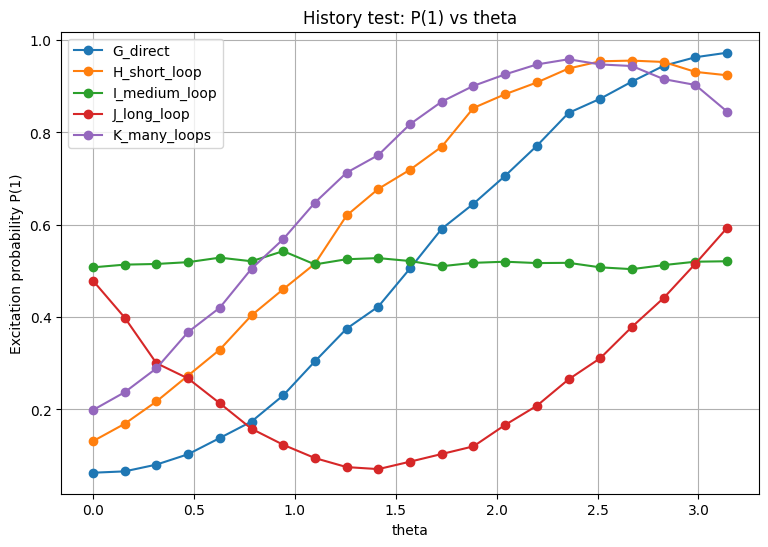

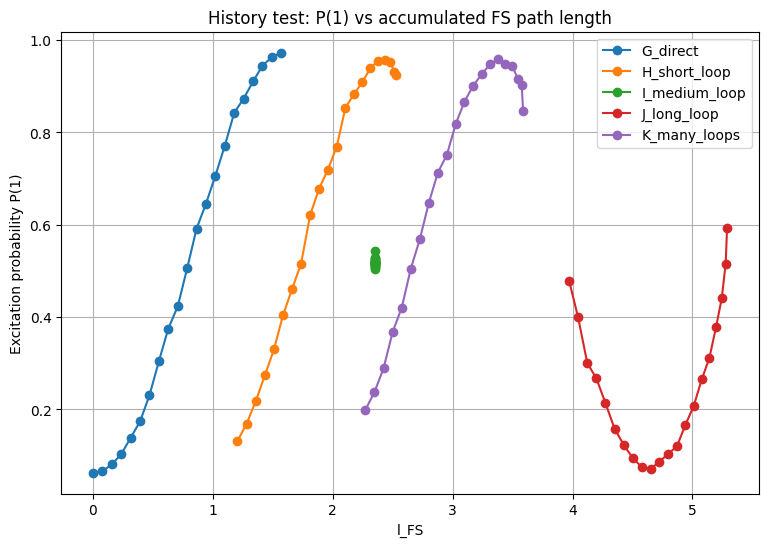

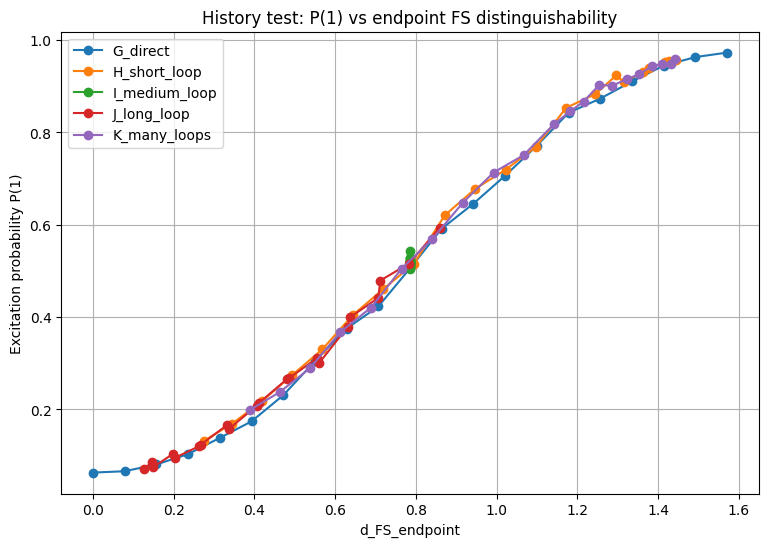

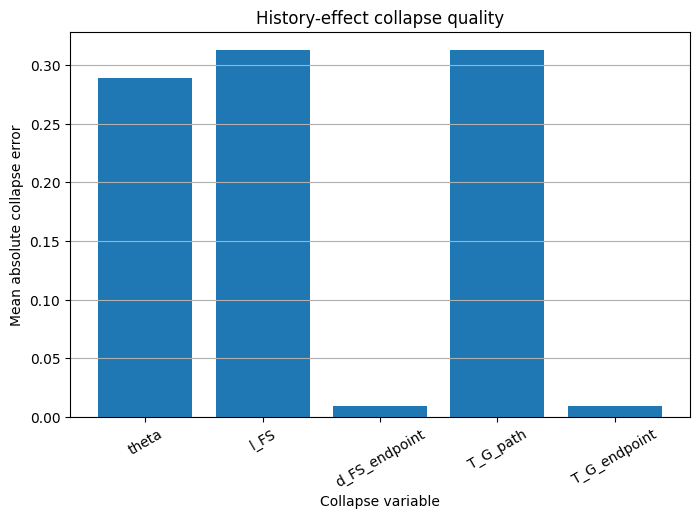

In [36]:
# ============================================================
# Analyze history-dependence test
# Requires existing df_history
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def history_collapse_error(df, x_col, y_col="P1_excitation", n_grid=300):
    protocols = sorted(df["protocol"].unique())

    x_min = max(df[df["protocol"] == p][x_col].min() for p in protocols)
    x_max = min(df[df["protocol"] == p][x_col].max() for p in protocols)

    grid = np.linspace(x_min, x_max, n_grid)

    interp = {}

    for p in protocols:
        sub = df[df["protocol"] == p].sort_values(x_col)
        sub = sub.drop_duplicates(subset=x_col)

        interp[p] = np.interp(
            grid,
            sub[x_col].values,
            sub[y_col].values
        )

    pair_errors = []

    for i, p1 in enumerate(protocols):
        for p2 in protocols[i+1:]:
            diff = np.abs(interp[p1] - interp[p2])

            pair_errors.append({
                "pair": f"{p1}__{p2}",
                "mean": diff.mean(),
                "rms": np.sqrt(np.mean(diff**2)),
                "max": diff.max()
            })

    pair_df = pd.DataFrame(pair_errors)

    summary = {
        "collapse_variable": x_col,
        "global_mean_abs_error": pair_df["mean"].mean(),
        "global_rms_error": pair_df["rms"].mean(),
        "global_max_abs_error": pair_df["max"].max()
    }

    return pair_df, summary


variables = [
    "theta",
    "l_FS",
    "d_FS_endpoint",
    "T_G_path",
    "T_G_endpoint"
]

summaries = []

for var in variables:
    pair_df, summary = history_collapse_error(df_history, var)
    summaries.append(summary)

summary_history_df = pd.DataFrame(summaries)

display(summary_history_df)

best = summary_history_df.sort_values("global_mean_abs_error").iloc[0]

print("\nBEST VARIABLE")
print("----------------")
print("Variable   :", best["collapse_variable"])
print("Mean error :", best["global_mean_abs_error"])
print("RMS error  :", best["global_rms_error"])
print("Max error  :", best["global_max_abs_error"])


# ============================================================
# Plots
# ============================================================

def plot_history(df, x_col, title):
    plt.figure(figsize=(9, 6))

    for protocol in sorted(df["protocol"].unique()):
        sub = df[df["protocol"] == protocol].sort_values(x_col)

        plt.plot(
            sub[x_col],
            sub["P1_excitation"],
            marker="o",
            label=protocol
        )

    plt.xlabel(x_col)
    plt.ylabel("Excitation probability P(1)")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()


plot_history(df_history, "theta", "History test: P(1) vs theta")
plot_history(df_history, "l_FS", "History test: P(1) vs accumulated FS path length")
plot_history(df_history, "d_FS_endpoint", "History test: P(1) vs endpoint FS distinguishability")


plt.figure(figsize=(8,5))

plt.bar(
    summary_history_df["collapse_variable"],
    summary_history_df["global_mean_abs_error"]
)

plt.ylabel("Mean absolute collapse error")
plt.xlabel("Collapse variable")
plt.title("History-effect collapse quality")
plt.xticks(rotation=30)
plt.grid(axis="y")
plt.show()

In [37]:
# ============================================================
# Hardest IBM test:
# 2-qubit entangling distinguishability-history experiment
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_ibm_runtime import SamplerV2 as Sampler

backend_name = "ibm_kingston"
# backend_name = "ibm_fez"
# backend_name = "ibm_marrakesh"

backend = service.backend(backend_name)
print("Selected backend:", backend.name)

shots = 4096
theta_values = np.linspace(0.0, np.pi, 17)
OMEGA = 2 * np.pi * 5e9


def fs_distance_statevectors(psi1, psi2):
    overlap = abs(np.vdot(psi1.data, psi2.data))
    overlap = np.clip(overlap, 0.0, 1.0)
    return np.arccos(overlap)


def endpoint_fs_distance_2q(steps):
    psi_i = Statevector.from_label("00")
    psi_f = Statevector.from_label("00")

    for step in steps:
        psi_f = psi_f.evolve(step)

    return fs_distance_statevectors(psi_i, psi_f)


def fs_path_length_2q(steps):
    psi = Statevector.from_label("00")
    total = 0.0

    for step in steps:
        psi_next = psi.evolve(step)
        total += fs_distance_statevectors(psi, psi_next)
        psi = psi_next

    return total


def final_state_2q(steps):
    psi = Statevector.from_label("00")
    for step in steps:
        psi = psi.evolve(step)
    return psi


def step_1q(gate_name, angle, qubit):
    qc = QuantumCircuit(2)
    getattr(qc, gate_name)(angle, qubit)
    return qc


def step_cx(control, target):
    qc = QuantumCircuit(2)
    qc.cx(control, target)
    return qc


def step_cz(q0, q1):
    qc = QuantumCircuit(2)
    qc.cz(q0, q1)
    return qc


def build_2q_measured_circuit(steps):
    qc = QuantumCircuit(2, 2)
    for step in steps:
        qc.compose(step, inplace=True)
    qc.measure([0, 1], [0, 1])
    return qc


# ------------------------------------------------------------
# Protocols
# ------------------------------------------------------------

def P0_product(theta):
    # product trajectory: Ry(theta) on qubit 0
    return [
        step_1q("ry", theta, 0)
    ]


def P1_bell_like(theta):
    # entangling path
    return [
        step_1q("ry", theta, 0),
        step_cx(0, 1)
    ]


def P2_entangle_uncompute(theta):
    # entangle and uncompute; endpoint can be close to product but history is entangling
    return [
        step_1q("ry", theta / 2, 0),
        step_cx(0, 1),
        step_1q("rz", theta, 1),
        step_cx(0, 1),
        step_1q("ry", theta / 2, 0)
    ]


def P3_loop_entangled(theta):
    # entangling loop plus final rotation
    return [
        step_1q("ry", theta / 3, 0),
        step_cx(0, 1),
        step_1q("rx", np.pi / 3, 1),
        step_cx(0, 1),
        step_1q("rx", -np.pi / 3, 1),
        step_1q("ry", 2 * theta / 3, 0)
    ]


def P4_cz_phase_path(theta):
    # phase-entangling path
    return [
        step_1q("ry", theta / 2, 0),
        step_1q("ry", theta / 2, 1),
        step_cz(0, 1),
        step_1q("rz", theta, 0),
        step_cz(0, 1),
        step_1q("ry", theta / 2, 0)
    ]


def P5_deep_mixed(theta):
    # deeper mixed entangling history
    return [
        step_1q("rx", theta / 4, 0),
        step_1q("ry", theta / 4, 1),
        step_cx(0, 1),
        step_1q("rz", theta / 2, 0),
        step_1q("rx", theta / 3, 1),
        step_cx(1, 0),
        step_1q("ry", theta / 3, 0),
        step_1q("rz", -theta / 2, 1),
        step_cx(0, 1),
        step_1q("ry", theta / 4, 0)
    ]


protocols = {
    "P0_product": P0_product,
    "P1_bell_like": P1_bell_like,
    "P2_entangle_uncompute": P2_entangle_uncompute,
    "P3_loop_entangled": P3_loop_entangled,
    "P4_cz_phase_path": P4_cz_phase_path,
    "P5_deep_mixed": P5_deep_mixed,
}


# ============================================================
# Build circuits and metadata
# ============================================================

circuits = []
metadata = []

for theta in theta_values:
    for label, maker in protocols.items():
        steps = maker(theta)

        l_FS = fs_path_length_2q(steps)
        d_FS_endpoint = endpoint_fs_distance_2q(steps)
        psi_f = final_state_2q(steps)

        # Ideal probabilities in computational basis
        probs = np.abs(psi_f.data) ** 2

        circuits.append(build_2q_measured_circuit(steps))

        metadata.append({
            "backend": backend_name,
            "protocol": label,
            "theta": theta,
            "l_FS": l_FS,
            "d_FS_endpoint": d_FS_endpoint,
            "T_G_path": l_FS / OMEGA,
            "T_G_endpoint": d_FS_endpoint / OMEGA,
            "ideal_P00": probs[0],
            "ideal_P01": probs[1],
            "ideal_P10": probs[2],
            "ideal_P11": probs[3]
        })

df_meta = pd.DataFrame(metadata)
display(df_meta.head(20))
print("Number of circuits:", len(circuits))


# ============================================================
# Run
# ============================================================

pm = generate_preset_pass_manager(
    backend=backend,
    optimization_level=1
)

isa_circuits = pm.run(circuits)

sampler = Sampler(mode=backend)

job = sampler.run(
    isa_circuits,
    shots=shots
)

print("Submitted job")
print("Backend:", backend_name)
print("Job ID:", job.job_id())
print("Waiting for result...")

result = job.result()


# ============================================================
# Extract results
# ============================================================

rows = []

for i, pub_result in enumerate(result):
    data = pub_result.data
    counts = None

    for name in dir(data):
        if name.startswith("_"):
            continue
        try:
            obj = getattr(data, name)
            if hasattr(obj, "get_counts"):
                counts = obj.get_counts()
                break
        except Exception:
            pass

    if counts is None:
        raise RuntimeError(f"Could not extract counts for circuit {i}")

    total = sum(counts.values())

    p00 = counts.get("00", 0) / total if total else np.nan
    p01 = counts.get("01", 0) / total if total else np.nan
    p10 = counts.get("10", 0) / total if total else np.nan
    p11 = counts.get("11", 0) / total if total else np.nan

    p_exc_total = 1 - p00

    rows.append({
        **metadata[i],
        "counts": str(counts),
        "shots": total,
        "P00": p00,
        "P01": p01,
        "P10": p10,
        "P11": p11,
        "P_exc_total": p_exc_total
    })

df_2q = pd.DataFrame(rows)

display(df_2q)

df_2q.to_csv(f"two_qubit_hard_test_{backend_name}.csv", index=False)
print("Saved:", f"two_qubit_hard_test_{backend_name}.csv")

qiskit_runtime_service.backends:WARNING:2026-06-04 16:23:00,434: Using instance: open-instance, plan: open


Selected backend: ibm_kingston


,backend,protocol,theta,l_FS,d_FS_endpoint,T_G_path,T_G_endpoint,ideal_P00,ideal_P01,ideal_P10,ideal_P11
0,ibm_kingston,P0_product,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,1.000000,0.000000,0.000000e+00,0.000000e+00
1,ibm_kingston,P1_bell_like,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,1.000000,0.000000,0.000000e+00,0.000000e+00
2,ibm_kingston,P2_entangle_uncompute,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,1.000000,0.000000,0.000000e+00,0.000000e+00
3,ibm_kingston,P3_loop_entangled,0.000000,1.047198,0.000000,3.333333e-11,0.000000e+00,1.000000,0.000000,0.000000e+00,0.000000e+00
4,ibm_kingston,P4_cz_phase_path,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,1.000000,0.000000,0.000000e+00,0.000000e+00
5,ibm_kingston,P5_deep_mixed,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,1.000000,0.000000,0.000000e+00,0.000000e+00
6,ibm_kingston,P0_product,0.196350,0.098175,0.098175,3.125000e-12,3.125000e-12,0.990393,0.009607,0.000000e+00,0.000000e+00
7,ibm_kingston,P1_bell_like,0.196350,0.236903,0.098175,7.540862e-12,3.125000e-12,0.990393,0.000000,0.000000e+00,9.607360e-03
8,ibm_kingston,P2_entangle_uncompute,0.196350,0.246585,0.097701,7.849060e-12,3.109904e-12,0.990485,0.009515,0.000000e+00,0.000000e+00
9,ibm_kingston,P3_loop_entangled,0.196350,1.237924,0.098175,3.940435e-11,3.125000e-12,0.990393,0.009607,1.287234e-38,2.996393e-36


Number of circuits: 102
Submitted job
Backend: ibm_kingston
Job ID: d8gqcqc2upec739k73i0
Waiting for result...


,backend,protocol,theta,l_FS,d_FS_endpoint,T_G_path,T_G_endpoint,ideal_P00,ideal_P01,ideal_P10,ideal_P11,counts,shots,P00,P01,P10,P11,P_exc_total
0,ibm_kingston,P0_product,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,0.000000,0.000000e+00,"{'00': 3858, '01': 234, '10': 4}",4096,0.941895,0.057129,0.000977,0.000000,0.058105
1,ibm_kingston,P1_bell_like,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,0.000000,0.000000e+00,"{'00': 3848, '11': 107, '01': 121, '10': 20}",4096,0.939453,0.029541,0.004883,0.026123,0.060547
2,ibm_kingston,P2_entangle_uncompute,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,0.000000,0.000000e+00,"{'01': 265, '00': 3829, '10': 2}",4096,0.934814,0.064697,0.000488,0.000000,0.065186
3,ibm_kingston,P3_loop_entangled,0.000000,1.047198,0.000000,3.333333e-11,0.000000e+00,1.000000e+00,0.000000e+00,0.000000,0.000000e+00,"{'00': 3840, '01': 220, '10': 32, '11': 4}",4096,0.937500,0.053711,0.007812,0.000977,0.062500
4,ibm_kingston,P4_cz_phase_path,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,0.000000,0.000000e+00,"{'00': 3841, '01': 255}",4096,0.937744,0.062256,0.000000,0.000000,0.062256
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
97,ibm_kingston,P1_bell_like,3.141593,3.141593,1.570796,1.000000e-10,5.000000e-11,3.749399e-33,0.000000e+00,0.000000,1.000000e+00,"{'11': 3566, '01': 414, '00': 109, '10': 7}",4096,0.026611,0.101074,0.001709,0.870605,0.973389
98,ibm_kingston,P2_entangle_uncompute,3.141593,5.235988,0.000000,1.666667e-10,0.000000e+00,1.000000e+00,3.852352e-33,0.000000,0.000000e+00,"{'00': 3799, '01': 260, '11': 17, '10': 20}",4096,0.927490,0.063477,0.004883,0.004150,0.072510
99,ibm_kingston,P3_loop_entangled,3.141593,4.063462,1.570796,1.293440e-10,5.000000e-11,4.605639e-32,1.000000e+00,0.000000,0.000000e+00,"{'01': 3936, '00': 131, '10': 4, '11': 25}",4096,0.031982,0.960938,0.000977,0.006104,0.968018
100,ibm_kingston,P4_cz_phase_path,3.141593,6.021386,0.785398,1.916667e-10,2.500000e-11,5.000000e-01,1.874700e-33,0.500000,2.403399e-33,"{'10': 1690, '00': 2096, '01': 160, '11': 150}",4096,0.511719,0.039062,0.412598,0.036621,0.488281


Saved: two_qubit_hard_test_ibm_kingston.csv


In [38]:
display(
    summary_2q_df[
        summary_2q_df["observable"]=="P_exc_total"
    ].sort_values("mean_error")
)

NameError: name 'summary_2q_df' is not defined

In [39]:
# ============================================================
# 2Q collapse analysis
# ============================================================

import numpy as np
import pandas as pd

def collapse_error_by_protocol(df, x_col, y_col, group_col="protocol", n_grid=300):

    groups = sorted(df[group_col].unique())

    x_min = max(df[df[group_col] == g][x_col].min() for g in groups)
    x_max = min(df[df[group_col] == g][x_col].max() for g in groups)

    grid = np.linspace(x_min, x_max, n_grid)

    interp = {}

    for g in groups:

        sub = df[df[group_col] == g].sort_values(x_col)
        sub = sub.drop_duplicates(subset=x_col)

        interp[g] = np.interp(
            grid,
            sub[x_col].values,
            sub[y_col].values
        )

    pair_errors = []

    for i, g1 in enumerate(groups):
        for g2 in groups[i+1:]:

            diff = np.abs(interp[g1] - interp[g2])

            pair_errors.append({
                "pair": f"{g1}__{g2}",
                "mean": diff.mean(),
                "rms": np.sqrt(np.mean(diff**2)),
                "max": diff.max()
            })

    pair_df = pd.DataFrame(pair_errors)

    summary = {
        "x_variable": x_col,
        "observable": y_col,
        "mean_error": pair_df["mean"].mean(),
        "rms_error": pair_df["rms"].mean(),
        "max_error": pair_df["max"].max()
    }

    return summary


x_vars = [
    "theta",
    "l_FS",
    "d_FS_endpoint",
    "T_G_path",
    "T_G_endpoint"
]

observables = [
    "P_exc_total",
    "P00",
    "P01",
    "P10",
    "P11"
]

rows = []

for obs in observables:
    for x in x_vars:

        rows.append(
            collapse_error_by_protocol(
                df_2q,
                x,
                obs
            )
        )

summary_2q_df = pd.DataFrame(rows)

display(summary_2q_df)

,x_variable,observable,mean_error,rms_error,max_error
0,theta,P_exc_total,0.184909,0.246627,0.900879
1,l_FS,P_exc_total,0.306993,0.308902,0.849142
2,d_FS_endpoint,P_exc_total,0.007206,0.008700,0.027242
3,T_G_path,P_exc_total,0.306993,0.308902,0.849142
4,T_G_endpoint,P_exc_total,0.007206,0.008700,0.027242
5,theta,P00,0.184909,0.246627,0.900879
6,l_FS,P00,0.306993,0.308902,0.849142
7,d_FS_endpoint,P00,0.007206,0.008700,0.027242
8,T_G_path,P00,0.306993,0.308902,0.849142
9,T_G_endpoint,P00,0.007206,0.008700,0.027242


In [40]:
# ============================================================
# Collect IBM technical metadata for Appendix A
# ============================================================

import json
import platform
import sys
import pandas as pd
from datetime import datetime, timezone

import qiskit
import qiskit_ibm_runtime

# ------------------------------------------------------------
# 1. Put all known jobs here
# ------------------------------------------------------------

job_registry = [
    {
        "experiment": "A-F one-qubit protocol test",
        "backend": "ibm_kingston",
        "job_id": "d8gq7nhe8nrc73bg8i00"
    },
    {
        "experiment": "A-F one-qubit protocol test",
        "backend": "ibm_fez",
        "job_id": "d8go594zupec739k32gg"
    },
    {
        "experiment": "A-F one-qubit protocol test",
        "backend": "ibm_marrakesh",
        "job_id": "PUT_MARRAKESH_JOB_ID_HERE"
    },
    {
        "experiment": "Bloch-sphere path test",
        "backend": "ibm_kingston",
        "job_id": "d8gpgtv8cos73f3i28g"
    },
    {
        "experiment": "History-loop test",
        "backend": "ibm_kingston",
        "job_id": "d8g7nhe8nrc73bgc960"
    },
    {
        "experiment": "Two-qubit entangling history test",
        "backend": "ibm_kingston",
        "job_id": "d8gqcc2upec739k73i0"
    }
]

# Remove placeholder rows automatically
job_registry = [
    row for row in job_registry
    if not row["job_id"].startswith("PUT_")
]


# ------------------------------------------------------------
# 2. System and package metadata
# ------------------------------------------------------------

environment_metadata = {
    "collection_time_utc": datetime.now(timezone.utc).isoformat(),
    "python_version": sys.version,
    "platform": platform.platform(),
    "qiskit_version": getattr(qiskit, "__version__", "unknown"),
    "qiskit_ibm_runtime_version": getattr(qiskit_ibm_runtime, "__version__", "unknown")
}

print("Environment metadata:")
print(json.dumps(environment_metadata, indent=2))


# ------------------------------------------------------------
# 3. Helper functions
# ------------------------------------------------------------

def safe_get(obj, attr, default=None):
    try:
        value = getattr(obj, attr)
        if callable(value):
            return value()
        return value
    except Exception:
        return default


def backend_summary(service, backend_name):
    backend = service.backend(backend_name)

    info = {
        "backend_name": backend_name,
        "backend_version": safe_get(backend, "version"),
        "backend_num_qubits": safe_get(backend, "num_qubits"),
        "backend_online_date": None,
        "backend_basis_gates": None,
        "backend_coupling_edges": None,
        "backend_processor_type": None
    }

    try:
        conf = backend.configuration()
        info["backend_basis_gates"] = ",".join(conf.basis_gates)
        info["backend_coupling_edges"] = len(conf.coupling_map) if conf.coupling_map else None
        info["backend_online_date"] = str(getattr(conf, "online_date", None))
        info["backend_processor_type"] = str(getattr(conf, "processor_type", None))
    except Exception:
        pass

    return info


def extract_job_metadata(service, row):
    backend_name = row["backend"]
    job_id = row["job_id"]

    out = {
        "experiment": row["experiment"],
        "backend": backend_name,
        "job_id": job_id
    }

    try:
        job = service.job(job_id)

        out["job_status"] = str(job.status())

        # Timestamps
        out["job_creation_date"] = str(safe_get(job, "creation_date"))
        out["job_created"] = str(safe_get(job, "created"))
        out["job_running"] = str(safe_get(job, "running"))
        out["job_done"] = str(safe_get(job, "done"))

        # Usage, metrics, options
        out["job_usage"] = json.dumps(safe_get(job, "usage", {}), default=str)
        out["job_metrics"] = json.dumps(safe_get(job, "metrics", {}), default=str)

        try:
            out["job_session_id"] = str(job.session_id)
        except Exception:
            out["job_session_id"] = None

        try:
            out["job_tags"] = json.dumps(job.tags(), default=str)
        except Exception:
            out["job_tags"] = None

        try:
            out["job_result_available"] = job.result() is not None
        except Exception:
            out["job_result_available"] = False

    except Exception as e:
        out["job_status"] = "ERROR"
        out["error"] = repr(e)

    try:
        out.update(backend_summary(service, backend_name))
    except Exception as e:
        out["backend_metadata_error"] = repr(e)

    return out


# ------------------------------------------------------------
# 4. Collect metadata
# ------------------------------------------------------------

job_metadata_rows = []

for row in job_registry:
    print("Collecting:", row["experiment"], row["backend"], row["job_id"])
    job_metadata_rows.append(
        extract_job_metadata(service, row)
    )

job_metadata_df = pd.DataFrame(job_metadata_rows)

display(job_metadata_df)

job_metadata_df.to_csv("ibm_job_metadata_for_appendix.csv", index=False)

with open("ibm_environment_metadata.json", "w") as f:
    json.dump(environment_metadata, f, indent=2)

print("Saved:")
print("ibm_job_metadata_for_appendix.csv")
print("ibm_environment_metadata.json")

Environment metadata:
{
  "collection_time_utc": "2026-06-04T16:33:44.377976+00:00",
  "python_version": "3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]",
  "platform": "Linux-6.6.122+-x86_64-with-glibc2.35",
  "qiskit_version": "2.4.1",
  "qiskit_ibm_runtime_version": "0.47.0"
}
Collecting: A-F one-qubit protocol test ibm_kingston d8gq7nhe8nrc73bg8i00


qiskit_runtime_service.backends:WARNING:2026-06-04 16:33:44,803: Using instance: open-instance, plan: open


Collecting: A-F one-qubit protocol test ibm_fez d8go594zupec739k32gg


qiskit_runtime_service.backends:WARNING:2026-06-04 16:33:46,226: Using instance: open-instance, plan: open
qiskit_runtime_service.backends:WARNING:2026-06-04 16:33:47,100: Using instance: open-instance, plan: open


Collecting: Bloch-sphere path test ibm_kingston d8gpgtv8cos73f3i28g
Collecting: History-loop test ibm_kingston d8g7nhe8nrc73bgc960


qiskit_runtime_service.backends:WARNING:2026-06-04 16:33:47,992: Using instance: open-instance, plan: open
qiskit_runtime_service.backends:WARNING:2026-06-04 16:33:48,684: Using instance: open-instance, plan: open


Collecting: Two-qubit entangling history test ibm_kingston d8gqcc2upec739k73i0


,experiment,backend,job_id,job_status,error,backend_name,backend_version,backend_num_qubits,backend_online_date,backend_basis_gates,backend_coupling_edges,backend_processor_type
0,A-F one-qubit protocol test,ibm_kingston,d8gq7nhe8nrc73bg8i00,ERROR,RuntimeJobNotFound('Job not found: d8gq7nhe8nr...,ibm_kingston,2,156,2025-02-20 05:00:00+00:00,"cz,id,rz,sx,x",352,"{'family': 'Heron', 'revision': '2'}"
1,A-F one-qubit protocol test,ibm_fez,d8go594zupec739k32gg,ERROR,RuntimeJobNotFound('Job not found: d8go594zupe...,ibm_fez,2,156,2024-05-14 04:00:00+00:00,"cz,id,rz,sx,x",352,"{'family': 'Heron', 'revision': '2'}"
2,Bloch-sphere path test,ibm_kingston,d8gpgtv8cos73f3i28g,ERROR,RuntimeJobNotFound('Job not found: d8gpgtv8cos...,ibm_kingston,2,156,2025-02-20 05:00:00+00:00,"cz,id,rz,sx,x",352,"{'family': 'Heron', 'revision': '2'}"
3,History-loop test,ibm_kingston,d8g7nhe8nrc73bgc960,ERROR,RuntimeJobNotFound('Job not found: d8g7nhe8nrc...,ibm_kingston,2,156,2025-02-20 05:00:00+00:00,"cz,id,rz,sx,x",352,"{'family': 'Heron', 'revision': '2'}"
4,Two-qubit entangling history test,ibm_kingston,d8gqcc2upec739k73i0,ERROR,RuntimeJobNotFound('Job not found: d8gqcc2upec...,ibm_kingston,2,156,2025-02-20 05:00:00+00:00,"cz,id,rz,sx,x",352,"{'family': 'Heron', 'revision': '2'}"


Saved:
ibm_job_metadata_for_appendix.csv
ibm_environment_metadata.json


In [41]:
import zipfile
import os

files_to_save = [
    "two_qubit_hard_test_ibm_kingston.csv",
    "ibm_job_metadata_for_appendix.csv",
    "ibm_environment_metadata.json"
]

zip_name = "IBM_results_archive.zip"

with zipfile.ZipFile(zip_name, "w") as z:
    for f in files_to_save:
        if os.path.exists(f):
            z.write(f)

print("Saved:", zip_name)

Saved: IBM_results_archive.zip


In [ ]:
# ============================================================
# Distinguishability Geometry Test
# ============================================================

theta_values = np.linspace(0.0, np.pi, 21)

OMEGA = 5e9 * 2*np.pi   # 5 GHz

def geometric_time(theta):
    # FS length for a qubit
    l_fs = theta / 2.0

    # T_G = l_FS / Delta
    return l_fs / OMEGA


def make_protocol_A(theta):

    qc = QuantumCircuit(1,1)

    qc.ry(theta,0)

    qc.measure(0,0)

    return qc


def make_protocol_B(theta):

    qc = QuantumCircuit(1,1)

    nsteps = 10

    for _ in range(nsteps):
        qc.ry(theta/nsteps,0)

    qc.measure(0,0)

    return qc


def make_protocol_C(theta):

    qc = QuantumCircuit(1,1)

    nsteps = 10

    for _ in range(nsteps):

        qc.rx(theta/(2*nsteps),0)

        qc.ry(theta/(2*nsteps),0)

    qc.measure(0,0)

    return qc


circuits = []
metadata = []

for theta in theta_values:

    qcA = make_protocol_A(theta)

    circuits.append(qcA)

    metadata.append({
        "protocol":"A",
        "theta":theta,
        "T_G":geometric_time(theta)
    })


    qcB = make_protocol_B(theta)

    circuits.append(qcB)

    metadata.append({
        "protocol":"B",
        "theta":theta,
        "T_G":geometric_time(theta)
    })


    qcC = make_protocol_C(theta)

    circuits.append(qcC)

    metadata.append({
        "protocol":"C",
        "theta":theta,
        "T_G":geometric_time(theta)
    })

qiskit_runtime_service.__init__:WARNING:2026-06-04 11:13:45,716: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-06-04 11:13:46,061: Loading instance: open-instance, plan: open
qiskit_runtime_service.backends:WARNING:2026-06-04 11:13:47,237: Using instance: open-instance, plan: open


Selected backend: ibm_marrakesh
Job ID: d8glrr66983c73dq0r5g
Waiting for result...


,protocol,theta,T_G,counts_0,counts_1,shots,P0_survival,P1_excitation
0,A,0.000000,0.000000e+00,2044,4,2048,0.998047,0.001953
1,B,0.000000,0.000000e+00,2045,3,2048,0.998535,0.001465
2,C,0.000000,0.000000e+00,2047,1,2048,0.999512,0.000488
3,A,0.157080,2.500000e-12,2038,10,2048,0.995117,0.004883
4,B,0.157080,2.500000e-12,2040,8,2048,0.996094,0.003906
...,...,...,...,...,...,...,...,...
58,B,2.984513,4.750000e-11,30,2018,2048,0.014648,0.985352
59,C,2.984513,4.750000e-11,529,1519,2048,0.258301,0.741699
60,A,3.141593,5.000000e-11,32,2016,2048,0.015625,0.984375
61,B,3.141593,5.000000e-11,28,2020,2048,0.013672,0.986328


Saved ibm_geometric_time_test.csv


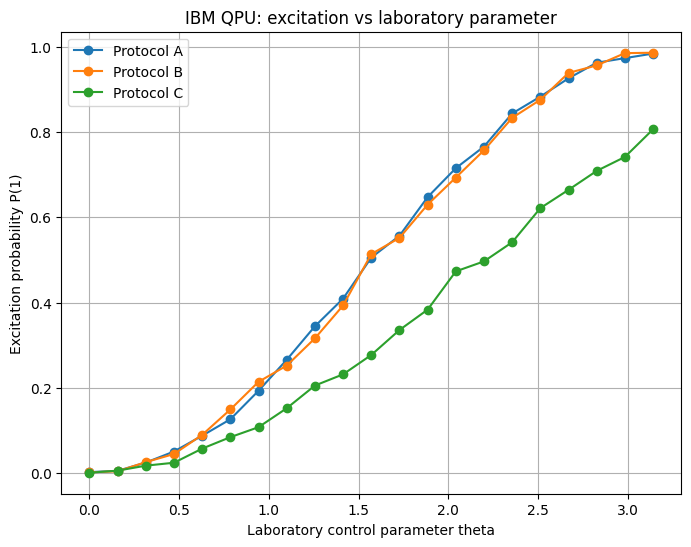

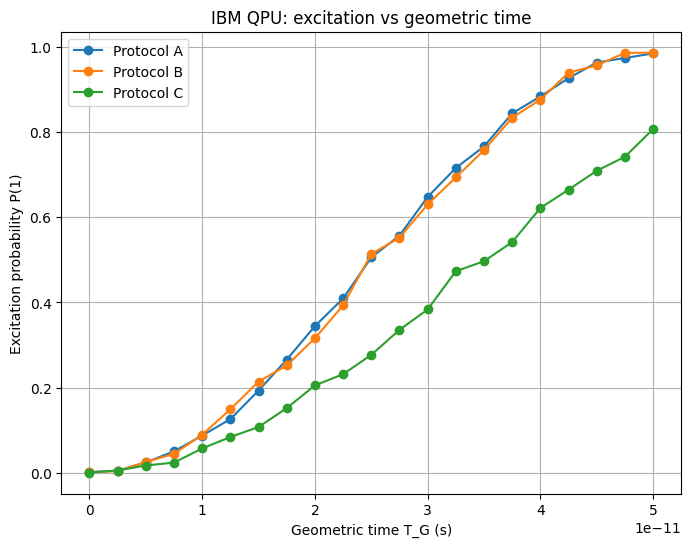

protocol,A,B,C,diff_A_B,diff_A_C
theta,,,,,
0.000000,0.001953,0.001465,0.000488,0.000488,0.001465
0.157080,0.004883,0.003906,0.005371,0.000977,0.000488
0.314159,0.024414,0.025391,0.017090,0.000977,0.007324
0.471239,0.050293,0.044434,0.023926,0.005859,0.026367
0.628319,0.087402,0.089355,0.057129,0.001953,0.030273
0.785398,0.125977,0.148926,0.083984,0.022949,0.041992
0.942478,0.192871,0.213867,0.107422,0.020996,0.085449
1.099557,0.265625,0.251953,0.151855,0.013672,0.113770
1.256637,0.344238,0.315918,0.205078,0.028320,0.139160


Mean differences:
diff_A_B 0.010672433035714286
diff_A_C 0.15899367559523808


In [ ]:
 import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from getpass import getpass

from qiskit import QuantumCircuit
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2 as Sampler

IBM_TOKEN = getpass("Enter NEW IBM Quantum token: ")

QiskitRuntimeService.save_account(
    channel="ibm_quantum_platform",
    token=IBM_TOKEN,
    overwrite=True
)

service = QiskitRuntimeService(channel="ibm_quantum_platform")

backend_name = None  # or "ibm_kingston", "ibm_fez", "ibm_marrakesh"

backend = service.least_busy(operational=True, simulator=False, min_num_qubits=1) if backend_name is None else service.backend(backend_name)
print("Selected backend:", backend.name)

theta_values = np.linspace(0.0, np.pi, 21)
OMEGA = 2 * np.pi * 5e9

def geometric_time(theta):
    return (theta / 2.0) / OMEGA

def make_protocol_A(theta):
    qc = QuantumCircuit(1, 1)
    qc.ry(theta, 0)
    qc.measure(0, 0)
    return qc

def make_protocol_B(theta):
    qc = QuantumCircuit(1, 1)
    nsteps = 10
    for _ in range(nsteps):
        qc.ry(theta / nsteps, 0)
    qc.measure(0, 0)
    return qc

def make_protocol_C(theta):
    qc = QuantumCircuit(1, 1)
    nsteps = 10
    for _ in range(nsteps):
        qc.rx(theta / (2 * nsteps), 0)
        qc.ry(theta / (2 * nsteps), 0)
    qc.measure(0, 0)
    return qc

circuits = []
metadata = []

for theta in theta_values:
    for label, maker in [("A", make_protocol_A), ("B", make_protocol_B), ("C", make_protocol_C)]:
        circuits.append(maker(theta))
        metadata.append({
            "protocol": label,
            "theta": theta,
            "T_G": geometric_time(theta)
        })

pm = generate_preset_pass_manager(backend=backend, optimization_level=1)
isa_circuits = pm.run(circuits)

sampler = Sampler(mode=backend)
job = sampler.run(isa_circuits, shots=2048)

print("Job ID:", job.job_id())
print("Waiting for result...")

result = job.result()

rows = []

for i, pub_result in enumerate(result):
    data = pub_result.data

    reg_names = [name for name in dir(data) if not name.startswith("_")]
    counts = None

    for name in reg_names:
        try:
            obj = getattr(data, name)
            if hasattr(obj, "get_counts"):
                counts = obj.get_counts()
                break
        except Exception:
            pass

    if counts is None:
        raise RuntimeError(f"Could not extract counts for circuit {i}. Available data: {data}")

    n0 = counts.get("0", 0)
    n1 = counts.get("1", 0)
    total = n0 + n1

    rows.append({
        **metadata[i],
        "counts_0": n0,
        "counts_1": n1,
        "shots": total,
        "P0_survival": n0 / total if total else np.nan,
        "P1_excitation": n1 / total if total else np.nan
    })

df = pd.DataFrame(rows)
display(df)

df.to_csv("ibm_geometric_time_test.csv", index=False)
print("Saved ibm_geometric_time_test.csv")

plt.figure(figsize=(8, 6))
for protocol in sorted(df["protocol"].unique()):
    sub = df[df["protocol"] == protocol]
    plt.plot(sub["theta"], sub["P1_excitation"], marker="o", label=f"Protocol {protocol}")

plt.xlabel("Laboratory control parameter theta")
plt.ylabel("Excitation probability P(1)")
plt.title("IBM QPU: excitation vs laboratory parameter")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 6))
for protocol in sorted(df["protocol"].unique()):
    sub = df[df["protocol"] == protocol]
    plt.plot(sub["T_G"], sub["P1_excitation"], marker="o", label=f"Protocol {protocol}")

plt.xlabel("Geometric time T_G (s)")
plt.ylabel("Excitation probability P(1)")
plt.title("IBM QPU: excitation vs geometric time")
plt.legend()
plt.grid(True)
plt.show()

pivot = df.pivot(index="theta", columns="protocol", values="P1_excitation")

if set(["A", "B"]).issubset(pivot.columns):
    pivot["diff_A_B"] = np.abs(pivot["A"] - pivot["B"])

if set(["A", "C"]).issubset(pivot.columns):
    pivot["diff_A_C"] = np.abs(pivot["A"] - pivot["C"])

display(pivot)

print("Mean differences:")
for col in pivot.columns:
    if str(col).startswith("diff"):
        print(col, pivot[col].mean())